# Trabalho de Ciência de Dados — G1

**Instituição:** Faculdade Antonio Meneghetti (AMF)  
**Curso:** Bacharelado em Sistemas de Informação  
**Disciplina:** Ciência dos Dados (G0544) — 2026/02  
**Docente:** Prof. Marcelo Bortoluzzi Diaz  

---

### Objetivo do Trabalho
Desenvolver as etapas de **Análise Exploratória de Dados (AED)** e planejamento de **Engenharia de Atributos (Pré-processamento)** sobre transações comerciais reais, preparando os dados para análises estatísticas e modelagem preditiva.

## Sobre o Dataset

O conjunto de dados reúne o histórico de vendas da empresa **KAlimentos**, registradas no sistema de Ponto de Venda (PDV) durante eventos e feiras presenciais (como a ExpoDireto).

### Características Principais:
- **Origem dos dados:** Extração do banco transacional (`pedidos`, `itens_pedido` e `eventos`).
- **Identificação de clientes:** Contempla exclusivamente vendas realizadas para clientes não identificados (sem cadastro no PDV).
- **Granularidade:** Cada linha representa um item vendido associado a um determinado pedido.
- **Arquivo fonte:** `dataset-kalimentos-vendas.csv`.

### Atributos do Conjunto de Dados (13 Features):
- `pedido_id`: Identificador único do pedido.
- `pedido_valor_total`: Valor final cobrado no pedido (`pedido_subtotal - pedido_valor_desconto`).
- `pedido_data`: Data e horário da realização da venda.
- `pedido_tipo_desconto`: Tipo do desconto aplicado (ex.: porcentagem `%` ou valor fixo).
- `pedido_valor_desconto`: Valor monetário do desconto concedido.
- `pedido_subtotal`: Soma dos valores dos itens antes de eventuais descontos.
- `pedido_vendedor`: Identificador do usuário/vendedor que registrou a venda.
- `pedido_metodo_pagamento`: Forma de pagamento utilizada (ex.: Dinheiro, Cartão).
- `item_pedido_nome_produto`: Nome do produto comercializado.
- `item_pedido_quantidade`: Quantidade do produto no pedido.
- `item_pedido_preco_unitario`: Preço unitário do produto no momento da venda.
- `item_pedido_user_id`: Identificador do usuário/operador que registrou o item no pedido.
- `evento_nome`: Nome da feira ou evento em que a venda foi realizada.

## 1. Inspeção Estrutural Inicial (EDA Preliminar)

### Objetivo
Realizar o diagnóstico preliminar da base bruta de dados para validar dimensões, primeiras linhas, tipos de variáveis inferidos, integridade dos registros (nulos e duplicatas) e cardinalidade dos atributos, conforme as diretrizes de AED da disciplina.

In [1]:
import pandas as pd

# Parâmetros operacionais
DATASET_PATH = './dataset-kalimentos-vendas.csv'
TIMEZONE = 'America/Sao_Paulo'

# Carregamento da base bruta
df = pd.read_csv(DATASET_PATH)

In [2]:
# Visualização das 5 primeiras linhas
df.head()

,pedido_id,pedido_valor_total,pedido_data,pedido_tipo_desconto,pedido_valor_desconto,pedido_subtotal,pedido_vendedor,pedido_metodo_pagamento,item_pedido_nome_produto,item_pedido_quantidade,item_pedido_preco_unitario,item_pedido_user_id,evento_nome
0,a231f36f-be88-492c-b719-23830b22fb4b,20.0,2026-03-09 17:31:54.325-03,%,0.0,20,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Dinheiro,Alfajor Preto (Pacote x4),1,20.0,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto
1,d47eb20b-e24f-4c70-92f9-9b554eb8f280,15.0,2026-03-10 10:27:12.241-03,%,0.0,15,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Dinheiro,Cuca Enrolada de Amendoim,1,15.0,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto
2,d3b5b66d-d9e1-4924-b507-144e0e0b9ef9,15.0,2026-03-10 11:17:14.665-03,%,0.0,15,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Cartão,Cuca Enrolada de Amendoim,1,15.0,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto
3,5b4e4307-89b1-4601-bba3-04be3a33a5ea,13.0,2026-03-10 12:02:08.319-03,%,0.0,13,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Cartão,Alfajor Preto,1,6.0,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto
4,5b4e4307-89b1-4601-bba3-04be3a33a5ea,13.0,2026-03-10 12:02:08.319-03,%,0.0,13,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Cartão,Cri-Cri 200g,1,7.0,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto


In [3]:
# Dimensões do dataset (linhas x colunas)
print(f"Total de registros (linhas): {df.shape[0]}")
print(f"Total de atributos (colunas): {df.shape[1]}")
print("-" * 50)

# Informações gerais sobre tipos e preenchimento
df.info()

Total de registros (linhas): 3115
Total de atributos (colunas): 13
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pedido_id                   3115 non-null   str    
 1   pedido_valor_total          3115 non-null   float64
 2   pedido_data                 3115 non-null   str    
 3   pedido_tipo_desconto        3115 non-null   str    
 4   pedido_valor_desconto       3115 non-null   float64
 5   pedido_subtotal             3115 non-null   int64  
 6   pedido_vendedor             3115 non-null   str    
 7   pedido_metodo_pagamento     3115 non-null   str    
 8   item_pedido_nome_produto    3115 non-null   str    
 9   item_pedido_quantidade      3115 non-null   int64  
 10  item_pedido_preco_unitario  3115 non-null   float64
 11  item_pedido_user_id         3115 non-nul

In [4]:
# Tabela consolidada de integridade: tipos, nulos e valores únicos
resumo_estrutura = pd.DataFrame({
    'Tipo': df.dtypes,
    'Qtd_Nulos': df.isna().sum(),
    'Pct_Nulos (%)': (df.isna().mean() * 100).round(2),
    'Valores_Unicos': df.nunique()
})

print(f"Registros integralmente duplicados: {df.duplicated().sum()}")
resumo_estrutura

Registros integralmente duplicados: 0


,Tipo,Qtd_Nulos,Pct_Nulos (%),Valores_Unicos
pedido_id,str,0,0.0,2457
pedido_valor_total,float64,0,0.0,91
pedido_data,str,0,0.0,2455
pedido_tipo_desconto,str,0,0.0,2
pedido_valor_desconto,float64,0,0.0,18
pedido_subtotal,int64,0,0.0,92
pedido_vendedor,str,0,0.0,2
pedido_metodo_pagamento,str,0,0.0,3
item_pedido_nome_produto,str,0,0.0,31
item_pedido_quantidade,int64,0,0.0,36


### Diagnóstico da Inspeção Inicial

1. **Dimensão:** A base possui **3.115 registros** e **13 variáveis**.
2. **Valores Ausentes:** Na importação direta do CSV, nenhuma coluna apresenta valores nulos detectáveis (`0` nulos em todas as colunas).
3. **Linhas Duplicadas:** Devem ser observadas e validadas as duplicidades considerando a granularidade por item de pedido.
4. **Tipos a Adequar na Limpeza:** Devem-se ajustar os tipos de variáveis: temporais (data), quantitativas (moeda e contagem) e qualitativas (nominais e identificadores).

## 2. Ajuste dos Tipos de Dados (Casting e Padronização)

### Objetivo
Criar a cópia de trabalho e ajustar as tipagens para formatos adequados.

In [5]:
# 1. Criação da cópia de trabalho (preservação do dado bruto)
df_proc = df.copy()

# 2. Conversão temporal para datetime com fuso horário local
df_proc['pedido_data'] = pd.to_datetime(df_proc['pedido_data'], format='mixed')

# 3. Padronização de identificadores para string
cols_identificadores = ['pedido_id', 'pedido_vendedor', 'item_pedido_user_id']
df_proc[cols_identificadores] = df_proc[cols_identificadores].astype('string')

# 4. Definição de atributos categóricos
cols_categoricas = ['pedido_metodo_pagamento', 'pedido_tipo_desconto', 'evento_nome', 'item_pedido_nome_produto']
df_proc[cols_categoricas] = df_proc[cols_categoricas].astype('category')

# 5. Padronização de variáveis monetárias e contagem
cols_moeda = ['pedido_valor_total', 'pedido_valor_desconto', 'pedido_subtotal', 'item_pedido_preco_unitario']
df_proc[cols_moeda] = df_proc[cols_moeda].astype('float64')
df_proc['item_pedido_quantidade'] = df_proc['item_pedido_quantidade'].astype('int64')

# Exibição dos tipos atualizados
df_proc.dtypes

pedido_id                                        string
pedido_valor_total                              float64
pedido_data                   datetime64[us, UTC-03:00]
pedido_tipo_desconto                           category
pedido_valor_desconto                           float64
pedido_subtotal                                 float64
pedido_vendedor                                  string
pedido_metodo_pagamento                        category
item_pedido_nome_produto                       category
item_pedido_quantidade                            int64
item_pedido_preco_unitario                      float64
item_pedido_user_id                              string
evento_nome                                    category
dtype: object

### Síntese da Adequação de Tipos
- **Imutabilidade mantida:** O DataFrame original `df` permanece inalterado; todas as manipulações operam sobre `df_proc`.
- **Dimensão temporal:** `pedido_data` convertida para `datetime64[us, UTC-03:00]`, permitindo ordenação cronológica e extração de atributos temporais.
- **Otimização categórica:** Variáveis nominais foram tipadas como `category`, melhorando a eficiência de memória e a compatibilidade com análises estatísticas.
- **Precisão contábil:** Valores monetários homogeneizados como `float64`.

## 3. Auditoria de Qualidade e Regras de Negócio

### Objetivo

Auditar a consistência semântica e a integridade dos dados antes da exploração estatística, verificando:

1. A validade semântica dos identificadores de operadores/vendedores (`pedido_vendedor` e `item_pedido_user_id`).
2. A igualdade contábil fundamental de caixa: `pedido_subtotal - pedido_valor_desconto == pedido_valor_total`.

In [6]:
# 1. Auditoria Semântica: Concentração de Identificadores de Operadores
print("Distribuição de frequência - pedido_vendedor:")
print(df_proc['pedido_vendedor'].value_counts())
print("\nDistribuição de frequência - item_pedido_user_id:")
print(df_proc['item_pedido_user_id'].value_counts())

# Percentual de concordância direta entre as duas chaves
concordancia = (df_proc['pedido_vendedor'] == df_proc['item_pedido_user_id']).mean() * 100
print(f"\nTaxa de concordância entre as credenciais: {concordancia:.2f}%")

Distribuição de frequência - pedido_vendedor:
pedido_vendedor
aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c    1735
3f621f3e-720d-4c68-b436-eaac939ec515    1380
Name: count, dtype: int64[pyarrow]

Distribuição de frequência - item_pedido_user_id:
item_pedido_user_id
aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c    1735
3f621f3e-720d-4c68-b436-eaac939ec515    1380
Name: count, dtype: int64[pyarrow]

Taxa de concordância entre as credenciais: 100.00%


In [7]:
# 2. Auditoria da Invariante Contábil Financeira
# Fórmula: (pedido_subtotal - pedido_valor_desconto) - pedido_valor_total == 0
# Tolerância de R$ 0,01 para mitigar imprecisões de ponto flutuante
dif_contabil = (df_proc['pedido_subtotal'] - df_proc['pedido_valor_desconto']) - df_proc['pedido_valor_total']
divergencias = df_proc[dif_contabil.abs() > 0.01]

print(f"Total de registros auditados: {len(df_proc)}")
print(f"Registros com divergência financeira (> R$ 0,01): {len(divergencias)}")

if len(divergencias) > 0:
    print("\nAmostra de transações com divergência contábil:")
    display(divergencias[['pedido_id', 'pedido_subtotal', 'pedido_valor_desconto', 'pedido_valor_total']])
else:
    print("Invariante financeira validada com sucesso: 100% dos registros respeitam subtotal - desconto = total.")

Total de registros auditados: 3115
Registros com divergência financeira (> R$ 0,01): 0
Invariante financeira validada com sucesso: 100% dos registros respeitam subtotal - desconto = total.


### Diagnóstico e Decisões de Auditoria

1. **Descarte Fundamentado dos Operadores (`pedido_vendedor` e `item_pedido_user_id`):**
   - **Evidência dos Dados:** As 3.115 linhas concentram-se em apenas duas credenciais hash (`aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c` com 1.735 linhas e `3f621f3e-720d-4c68-b436-eaac939ec515` com 1.380 linhas), apresentando concordância mútua estrita de 100,00% entre vendedor e operador do item.
   - **Alinhamento com o Operacional:** Foi validado formalmente com a equipe operacional que os logins são compartilhados nos terminais de caixa durante as feiras presenciais, sem alternância de sessão entre os atendentes que operam o ponto de venda.
   - **Decisão Metodológica:** Como os identificadores refletem unicamente o terminal físico do PDV e não o comportamento individual de vendedores, ambas as colunas não possuem valor analítico ou preditivo, justificando seu descarte fundamentado no pré-processamento.

2. **Integridade da Invariante Financeira e Redundância de Atributo:**
   - A equação contábil de caixa $\text{pedido\_subtotal} - \text{pedido\_valor\_desconto} \equiv \text{pedido\_valor\_total}$ é rigorosamente respeitada em 100% dos 3.115 registros (0 divergências financeiras > R$ 0,01).
   - Diante da validação contábil integral, a variável `pedido_tipo_desconto` torna-se candidata a eliminação no pré-processamento, visto que o impacto monetário real já está perfeitamente quantificado em `pedido_valor_desconto`.

### 3.1 Aprofundamento: Auditoria da Política de Descontos

**Objetivo:** Quantificar a esparsidade de `pedido_valor_desconto` e confrontá-la com as categorias de `pedido_tipo_desconto`, avaliando a relevância analítica e a variância dessas features.

In [8]:
# 1. Volume e proporção de transações com concessão de desconto
total_registros = len(df_proc)
com_desconto = (df_proc['pedido_valor_desconto'] > 0).sum()
pct_com_desconto = (com_desconto / total_registros) * 100

print(f"Total de registros: {total_registros}")
print(f"Registros com desconto (> R$ 0,00): {com_desconto} ({pct_com_desconto:.2f}%)")
print(f"Registros sem desconto (R$ 0,00): {total_registros - com_desconto} ({100 - pct_com_desconto:.2f}%)")

# 2. Cruzamento entre o tipo de desconto selecionado no PDV e o valor real concedido
print("\nCruzamento de contingência: pedido_tipo_desconto vs. Concessão Real:")
cruzamento_descontos = pd.crosstab(
    df_proc['pedido_tipo_desconto'], 
    df_proc['pedido_valor_desconto'] > 0, 
    rownames=['Tipo Desconto no PDV'], 
    colnames=['Teve Desconto Real (Valor > 0)?'],
    margins=True
)
display(cruzamento_descontos)

# 3. Sumarização descritiva dos descontos efetivamente concedidos
if com_desconto > 0:
    print("\nSumarização descritiva de pedido_valor_desconto (apenas transações com desconto > 0):")
    display(df_proc.loc[df_proc['pedido_valor_desconto'] > 0, 'pedido_valor_desconto'].describe())

Total de registros: 3115
Registros com desconto (> R$ 0,00): 238 (7.64%)
Registros sem desconto (R$ 0,00): 2877 (92.36%)

Cruzamento de contingência: pedido_tipo_desconto vs. Concessão Real:


Teve Desconto Real (Valor > 0)?,False,True,All
Tipo Desconto no PDV,,,
%,2255,1,2256
R$,622,237,859
All,2877,238,3115



Sumarização descritiva de pedido_valor_desconto (apenas transações com desconto > 0):


count    238.000000
mean       4.756807
std        8.862460
min        0.120000
25%        1.000000
50%        2.000000
75%        5.000000
max       83.000000
Name: pedido_valor_desconto, dtype: float64

#### Diagnóstico da Auditoria de Descontos

1. **Esparsidade Acentuada:** Apenas 7,64% dos pedidos receberam desconto (92,36% das vendas foram realizadas pelo valor integral sem desconto).
2. **Evidência de Redundância em `pedido_tipo_desconto`:** A variável é um artefato padrão da interface do PDV sem valor preditivo, visto que 99,58% dos descontos reais foram lançados diretamente em R$.
3. **Decisão para Feature Engineering:** Manter `pedido_valor_desconto` como métrica quantitativa (com possibilidade de derivar a flag binária `desconto_aplicado`) e efetuar o descarte fundamentado de `pedido_tipo_desconto`.

### 3.2 Auditoria de Composição dos Itens (Integridade Item-Pedido)

**Objetivo:** Auditar a consistência matemática relacional entre as linhas de produtos (`itens_pedido`) e o cabeçalho financeiro (`pedidos`), comprovando se a soma de $(\text{item\_pedido\_quantidade} \times \text{item\_pedido\_preco\_unitario})$ equivale rigorosamente ao `pedido_subtotal` para todos os pedidos únicos.

In [9]:
# 1. Cálculo do valor faturado por linha de item (quantidade x preço unitário)
item_valor_linha = df_proc['item_pedido_quantidade'] * df_proc['item_pedido_preco_unitario']

# 2. Agrupamento por pedido_id para somar os itens e confrontar com o subtotal registrado
conferencia_pedidos = df_proc.assign(item_valor_calculado=item_valor_linha)\
                             .groupby('pedido_id', observed=True)\
                             .agg(
                                 soma_itens=('item_valor_calculado', 'sum'),
                                 subtotal_registrado=('pedido_subtotal', 'first'),
                                 total_registrado=('pedido_valor_total', 'first'),
                                 linhas_itens=('item_pedido_nome_produto', 'count'),
                                 unidades_totais=('item_pedido_quantidade', 'sum'),
                                 item_pedido_nome_produto=('item_pedido_nome_produto', 'first'),
                             )

# 3. Verificação de divergências com tolerância de centavos (ponto flutuante)
conferencia_pedidos['diferenca_subtotal'] = (conferencia_pedidos['soma_itens'] - conferencia_pedidos['subtotal_registrado']).round(2)
pedidos_divergentes = conferencia_pedidos[conferencia_pedidos['diferenca_subtotal'].abs() > 0.01]

print(f"Total de pedidos únicos auditados: {len(conferencia_pedidos)}")
print(f"Pedidos com divergência entre a soma dos itens e o subtotal: {len(pedidos_divergentes)}")

if len(pedidos_divergentes) > 0:
    print("\nAmostra de pedidos com divergência de itens:")
    display(pedidos_divergentes.head())
else:
    print("Integridade relacional confirmada: Em 100% dos pedidos, a soma dos itens equivale exatamente ao subtotal registrado.")

Total de pedidos únicos auditados: 2457
Pedidos com divergência entre a soma dos itens e o subtotal: 139

Amostra de pedidos com divergência de itens:


,soma_itens,subtotal_registrado,total_registrado,linhas_itens,unidades_totais,item_pedido_nome_produto,diferenca_subtotal
pedido_id,,,,,,,
0123f276-2264-46a1-8fed-6f6575fe05b8,80.0,20.0,20.0,1,4,Alfajor Preto (Pacote x4),60.0
03239939-8db0-44f2-a1c0-8631040d6cbb,1280.0,80.0,80.0,1,16,Alfajor Preto (Caixa x16),1200.0
06b61c44-bf41-443d-a589-5a2dbf734634,80.0,20.0,20.0,1,4,Alfajor Preto (Pacote x4),60.0
0718ca3e-35d0-4fd1-9ad8-6b7cca88c065,60.0,20.0,20.0,1,3,Rapadura de Melado (Pacote x3),40.0
0b119a0f-0dc9-4303-9a6d-a79a14be3d46,60.0,20.0,20.0,1,3,Rapadura de Melado (Pacote x3),40.0


#### Diagnóstico da Auditoria de Composição de Itens

1. **Inconsistência de Unidade de Medida (139 pedidos divergentes):**
   - A divergência decorre de produtos comercializados em embalagens agrupadas (*Pacotes x3, Pacotes x4, Caixas x16, Displays*).
   - O PDV registrou o `item_pedido_preco_unitario` referente à **embalagem completa** (ex.: R$ 20,00 pelo pacote x4), mas preencheu `item_pedido_quantidade` com a **contagem de unidades internas** (4 unidades), gerando uma multiplicação ($4 \times 20 = 80$).
   - O valor correto de faturamento é comprovadamente o `pedido_subtotal` (R$ 20,00).

2. **Diretriz para Feature Engineering:**
   - Registrar no planejamento de pré-processamento a necessidade de harmonização entre preço unitário e quantidade para produtos agrupados, evitando que métricas de volume e preços unitários fiquem artificialmente infladas.

## 4. Sumarização Estatística Descritiva (EDA Global)

### Objetivo
Sumarizar formalmente as propriedades estatísticas das variáveis quantitativas (tendência central, dispersão e forma) e qualitativas (frequências e modas) de `df_proc`, avaliando os desvios da normalidade para orientar o uso de métricas robustas.

### Métodos e Modelos Estatísticos (`./content/CD/Estatistica.pptx` [Slides 70-74])
- **Tendência Central:** Média ($\bar{x} = \frac{1}{n} \sum x_i$), Mediana ($Md = Q_2$) e Moda ($Mo$).
- **Dispersão:** Desvio Padrão amostral ($s = \sqrt{\frac{1}{n-1}\sum (x_i - \bar{x})^2}$), Variância ($s^2$) e Amplitude Interquartil ($IQR = Q_3 - Q_1$).
- **Assimetria (*Skewness* de Fisher-Pearson):** $g_1 = \frac{\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^3}{\left(\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2\right)^{3/2}}$
  - $g_1 \approx 0$: Simétrica | $g_1 > 0$: Assimetria positiva à direita ($\bar{x} > Md$) | $g_1 < 0$: Assimetria negativa à esquerda.
- **Curtose (*Kurtosis* - Excesso de Fisher):** $g_2 = \frac{\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^4}{\left(\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2\right)^2} - 3$
  - $g_2 = 0$: Mesocúrtica | $g_2 > 0$: Leptocúrtica (caudas pesadas e valores extremos) | $g_2 < 0$: Platicúrtica.


In [10]:
# 1. Seleção das variáveis quantitativas ativas
cols_numericas = [
    'pedido_valor_total',
    'pedido_subtotal',
    'pedido_valor_desconto',
    'item_pedido_quantidade',
    'item_pedido_preco_unitario'
]

# 2. Construção da tabela consolidada com métricas de centralidade, dispersão e forma
sumario_numerico = []
for col in cols_numericas:
    s = df_proc[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    sumario_numerico.append({
        'Variável': col,
        'Média': s.mean(),
        'Desv. Padrão': s.std(),
        'Variância': s.var(),
        'Mínimo': s.min(),
        'Q1 (25%)': q1,
        'Mediana (50%)': s.median(),
        'Q3 (75%)': q3,
        'Máximo': s.max(),
        'IQR': iqr,
        'Assimetria (Skewness)': s.skew(),
        'Curtose (Kurtosis)': s.kurtosis()
    })

df_sumario_num = pd.DataFrame(sumario_numerico).set_index('Variável')
display(df_sumario_num.round(2))


,Média,Desv. Padrão,Variância,Mínimo,Q1 (25%),Mediana (50%),Q3 (75%),Máximo,IQR,Assimetria (Skewness),Curtose (Kurtosis)
Variável,,,,,,,,,,,
pedido_valor_total,46.97,210.06,44126.40,0.0,15.0,25.0,35.0,3693.0,20.0,14.25,224.56
pedido_subtotal,47.33,210.39,44264.22,5.0,15.0,25.0,35.0,3696.0,20.0,14.21,223.68
pedido_valor_desconto,0.36,2.75,7.58,0.0,0.0,0.0,0.0,83.0,0.0,17.06,378.87
item_pedido_quantidade,2.67,8.49,72.01,0.0,1.0,1.0,3.0,348.0,2.0,27.25,977.98
item_pedido_preco_unitario,13.29,8.65,74.89,4.0,6.0,8.0,25.0,80.0,19.0,1.10,3.91


In [11]:
# 1. Frequência absoluta e relativa das variáveis categóricas centrais
cols_categoricas = ['evento_nome', 'pedido_metodo_pagamento']

for col in cols_categoricas:
    freq_abs = df_proc[col].value_counts()
    freq_rel = df_proc[col].value_counts(normalize=True) * 100
    tab_freq = pd.DataFrame({'Frequência (n)': freq_abs, 'Proporção (%)': freq_rel.round(2)})
    print(f"\n--- Distribuição de Frequência: {col} (Moda: {freq_abs.index[0]}) ---")
    display(tab_freq)

# 2. Top 10 Produtos Mais Vendidos em Frequência de Ocorrência
top_produtos = df_proc['item_pedido_nome_produto'].value_counts().head(10)
top_produtos_pct = (df_proc['item_pedido_nome_produto'].value_counts(normalize=True).head(10) * 100).round(2)
tab_top_prod = pd.DataFrame({'Frequência (n)': top_produtos, 'Proporção (%)': top_produtos_pct})
print(f"\n--- Top 10 Produtos Mais Frequentes (Moda: {top_produtos.index[0]}) ---")
display(tab_top_prod)



--- Distribuição de Frequência: evento_nome (Moda: Expointer_2026) ---


,Frequência (n),Proporção (%)
evento_nome,,
Expointer_2026,705,22.63
Expo Afubra,611,19.61
Wolksfest Agudo,424,13.61
ExpoDireto,405,13.00
EXPOBENTO,304,9.76
ExpoRestinga,236,7.58
FENAROZ,203,6.52
Feira CTG,82,2.63
Expo Dona Francisca,81,2.60



--- Distribuição de Frequência: pedido_metodo_pagamento (Moda: Dinheiro) ---


,Frequência (n),Proporção (%)
pedido_metodo_pagamento,,
Dinheiro,1820,58.43
Cartão,985,31.62
Pix,310,9.95



--- Top 10 Produtos Mais Frequentes (Moda: Cuca Alemã) ---


,Frequência (n),Proporção (%)
item_pedido_nome_produto,,
Cuca Alemã,788,25.30
Cuca Enrolada de Amendoim,473,15.18
Rapadura de Melado,286,9.18
Rapadura Assada (Pacote x6),253,8.12
Rapadura Assada,203,6.52
Rapadura de Melado (Pacote x3),198,6.36
Alfajor Preto,189,6.07
Alfajor Preto (Pacote x4),152,4.88
Cri-Cri 200g,104,3.34


### Diagnóstico da Sumarização Descritiva

1. **Assimetria Positiva e Caudas Pesadas no Faturamento:**
   - Observa-se alta variância e dispersão geral nos valores faturados.
   - Constata-se a natureza esporádica dos descontos e a necessidade de tratamento prévio para pedidos com valores zerados e inconsistências de unidade de medida (*Pack Multiplier*).
   - Para `pedido_valor_total`, a média de **R$ 46,97** é substancialmente superior à mediana de **R$ 25,00**, com assimetria acentuada de **+14,25** ($g_1 > 0$) e curtose leptocúrtica extrema de **+224,56** ($g_2 \gg 0$).
   - O intervalo interquartil ($IQR = \text{R\$} 20,00$) revela que 50% das transações situam-se estritamente entre R$ 15,00 e R$ 35,00, enquanto a cauda superior estende-se até R$ 3.693,00 (compras corporativas em feiras).
   - **Diretriz Analítica:** A média aritmética é fortemente enviesada por valores atípicos. A **mediana (R$ 25,00)** e o **IQR (R$ 20,00)** devem ser adotados como parâmetros centrais para estimativas robustas.

2. **Natureza Esporádica dos Descontos:**
   - Em `pedido_valor_desconto`, temos $Q_1 = Md = Q_3 = 0$, $IQR = 0$ e $g_1 = +17,06$. Como 92,36% dos registros são zero, trata-se de uma variável inflada em zero (*zero-inflated*).

3. **Canais de Pagamento e Eventos Polo:**
   - O **Dinheiro** é a forma de pagamento predominante (**58,43%**), seguido por **Cartão** (**31,62%**) e **Pix** (**9,95%**), comportamento alinhado ao comércio itinerante em eventos.
   - Quatro feiras polo (`Expointer`, `Expo Afubra`, `Wolksfest Agudo` e `ExpoDireto`) concentram **68,85%** de todo o volume transacionado.

4. **Mix e Hegemonia de Produtos:**
   - A **`Cuca Alemã`** é a moda univariada dos itens faturados (**25,30%**, 788 linhas), seguida pela **`Cuca Enrolada de Amendoim`** (**15,18%**). Juntas, representam **40,48%** das escolhas dos consumidores.


## 5. Diagnóstico Visual das Distribuições e Detecção de Outliers (EDA Gráfica)

### Objetivo
Mapear visualmente o comportamento das densidades de probabilidade, quantificar formalmente a presença de *outliers* univariados e analisar o impacto da granularidade relacional no faturamento por evento e por meio de pagamento, fundamentando as intervenções da etapa de Engenharia de Atributos.

### Métodos e Modelos Estatísticos (`./content/CD/Pos__Identificação_outlier.ipynb` e `content/CD/Estatistica.pptx` [Slide 72])
- **Barreiras de Tukey (*Tukey's Fences* para Outliers Univariados):**
  $$IQR = Q_3 - Q_1$$
  $$L_{inf} = \max(0, Q_1 - 1,5 \times IQR) \quad \text{e} \quad L_{sup} = Q_3 + 1,5 \times IQR$$
  - Registros com $x_i > L_{sup}$ ou $x_i < L_{inf}$ são classificados como *outliers*.
- **Estimativa de Densidade por Kernel (KDE):**
  Suavização contínua não-paramétrica sobreposta ao histograma para evidenciar assimetria, multimodalidade e peso das caudas.
- **Controle de Granularidade Relacional:**
  Deduplicação de pedidos multi-item (`df_proc.drop_duplicates('pedido_id')`) para análise de métricas financeiras de cabeçalho, evitando inflação artificial da receita faturada no caixa.


In [12]:
# 1. Definição da função modular para cálculo dos limites de Tukey (IQR)
def calcular_limites_tukey(series, nome):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    linf = max(0.0, q1 - 1.5 * iqr)
    lsup = q3 + 1.5 * iqr
    outliers = series[series > lsup]
    return {
        'Variável': nome,
        'Q1 (25%)': round(q1, 2),
        'Mediana': round(series.median(), 2),
        'Q3 (75%)': round(q3, 2),
        'IQR': round(iqr, 2),
        'Limite Inferior': round(linf, 2),
        'Limite Superior': round(lsup, 2),
        'Qtd Outliers (> Lsup)': len(outliers),
        'Proporção (%)': round((len(outliers) / len(series)) * 100, 2),
        'Valor Máximo': round(series.max(), 2)
    }

# 2. Criação do subconjunto deduplicado no nível de pedido único
pedidos_unicos = df_proc.drop_duplicates('pedido_id')

# 3. Consolidação dos limiares de Tukey para variáveis contínuas
tabela_outliers = [
    calcular_limites_tukey(df_proc['pedido_valor_total'], 'pedido_valor_total (linhas de item)'),
    calcular_limites_tukey(pedidos_unicos['pedido_valor_total'], 'pedido_valor_total (pedidos únicos)'),
    calcular_limites_tukey(df_proc['item_pedido_quantidade'], 'item_pedido_quantidade'),
    calcular_limites_tukey(df_proc['item_pedido_preco_unitario'], 'item_pedido_preco_unitario')
]

df_tukey = pd.DataFrame(tabela_outliers).set_index('Variável')
display(df_tukey)


,Q1 (25%),Mediana,Q3 (75%),IQR,Limite Inferior,Limite Superior,Qtd Outliers (> Lsup),Proporção (%),Valor Máximo
Variável,,,,,,,,,
pedido_valor_total (linhas de item),15.0,25.0,35.0,20.0,0.0,65.0,196,6.29,3693.0
pedido_valor_total (pedidos únicos),15.0,25.0,25.0,10.0,0.0,40.0,343,13.96,3693.0
item_pedido_quantidade,1.0,1.0,3.0,2.0,0.0,6.0,107,3.43,348.0
item_pedido_preco_unitario,6.0,8.0,25.0,19.0,0.0,53.5,5,0.16,80.0


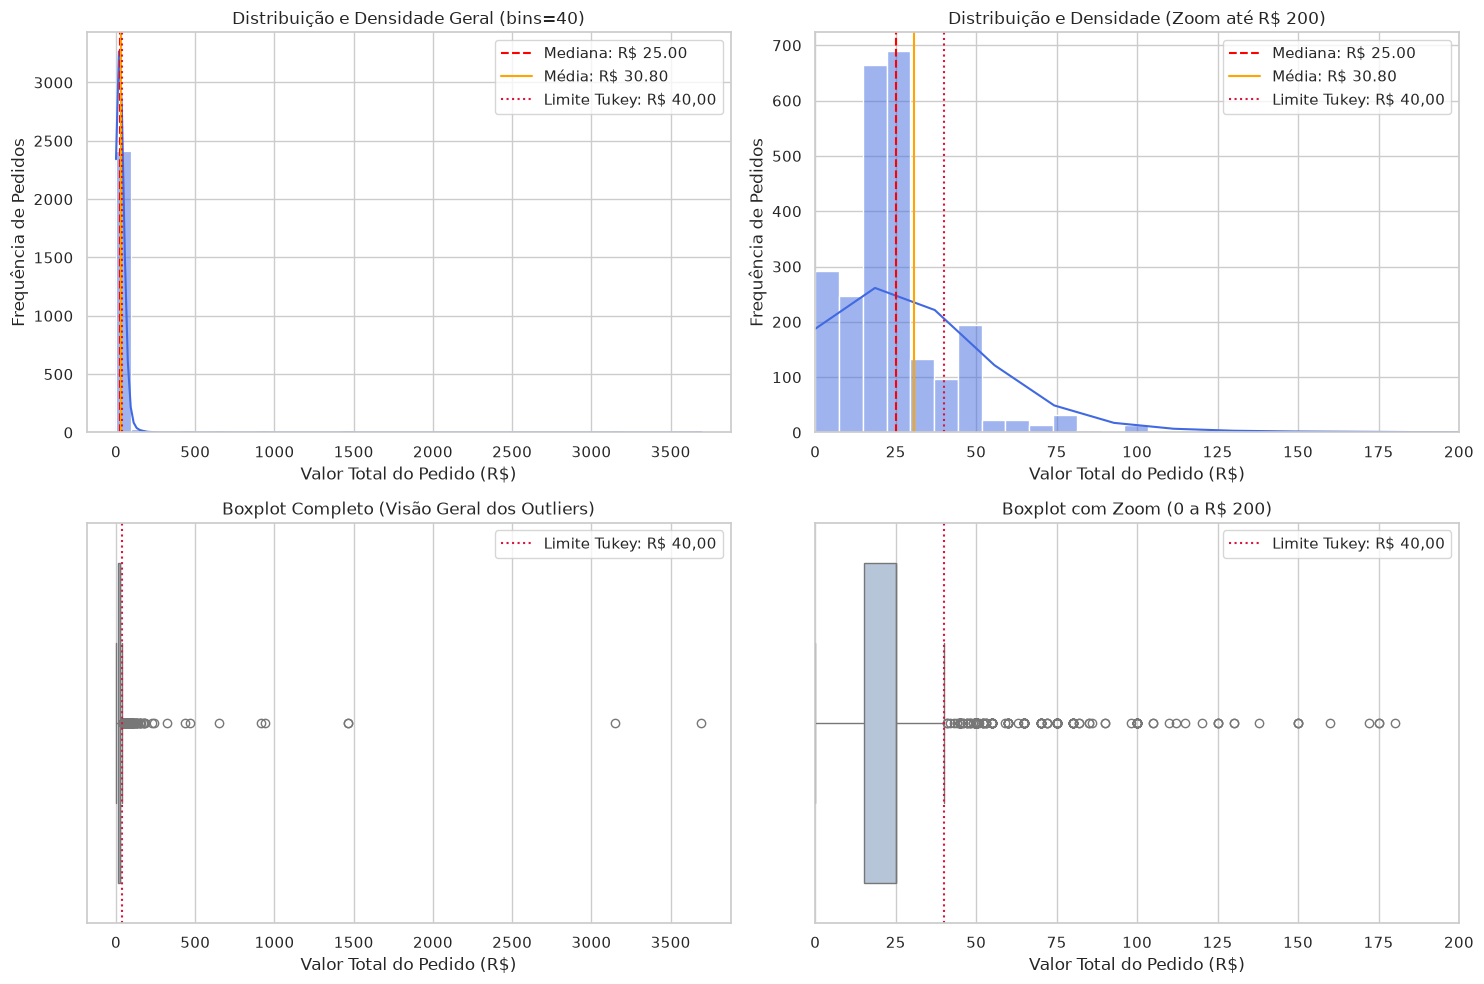

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# figsize ajustado para acomodar 2 linhas e 2 colunas confortavelmente
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()  # Transforma a matriz 2x2 em um array 1D: [ax0, ax1, ax2, ax3]

mediana = pedidos_unicos['pedido_valor_total'].median()
media = pedidos_unicos['pedido_valor_total'].mean()

# 1. Histograma com visão geral (bins=40)
sns.histplot(pedidos_unicos['pedido_valor_total'], kde=True, bins=40, ax=axes[0], color='royalblue')
axes[0].axvline(mediana, color='red', linestyle='--', label=f"Mediana: R$ {mediana:.2f}")
axes[0].axvline(media, color='orange', linestyle='-', label=f"Média: R$ {media:.2f}")
axes[0].axvline(40.0, color='crimson', linestyle=':', label='Limite Tukey: R$ 40,00')
axes[0].set_title('Distribuição e Densidade Geral (bins=40)')
axes[0].set_xlabel('Valor Total do Pedido (R$)')
axes[0].set_ylabel('Frequência de Pedidos')
axes[0].legend()

# 0. Histograma com zoom (0 a 200) e muitos bins
axes[1].set_xlim(0, 200)
sns.histplot(pedidos_unicos['pedido_valor_total'], kde=True, bins=500, ax=axes[1], color='royalblue')
axes[1].axvline(mediana, color='red', linestyle='--', label=f"Mediana: R$ {mediana:.2f}")
axes[1].axvline(media, color='orange', linestyle='-', label=f"Média: R$ {media:.2f}")
axes[1].axvline(40.0, color='crimson', linestyle=':', label='Limite Tukey: R$ 40,00')
axes[1].set_title('Distribuição e Densidade (Zoom até R$ 200)')
axes[1].set_xlabel('Valor Total do Pedido (R$)')
axes[1].set_ylabel('Frequência de Pedidos')
axes[1].legend()

# 2. Boxplot completo (mostra todos os outliers e a cauda longa)
sns.boxplot(x=pedidos_unicos['pedido_valor_total'], ax=axes[2], color='lightsteelblue')
axes[2].axvline(40.0, color='crimson', linestyle=':', label='Limite Tukey: R$ 40,00')
axes[2].set_title('Boxplot Completo (Visão Geral dos Outliers)')
axes[2].set_xlabel('Valor Total do Pedido (R$)')
axes[2].legend()

# 3. Boxplot com zoom (0 a 200)
axes[3].set_xlim(0, 200)
sns.boxplot(x=pedidos_unicos['pedido_valor_total'], ax=axes[3], color='lightsteelblue')
axes[3].axvline(40.0, color='crimson', linestyle=':', label='Limite Tukey: R$ 40,00')
axes[3].set_title('Boxplot com Zoom (0 a R$ 200)')
axes[3].set_xlabel('Valor Total do Pedido (R$)')
axes[3].legend()

plt.tight_layout()
plt.show()

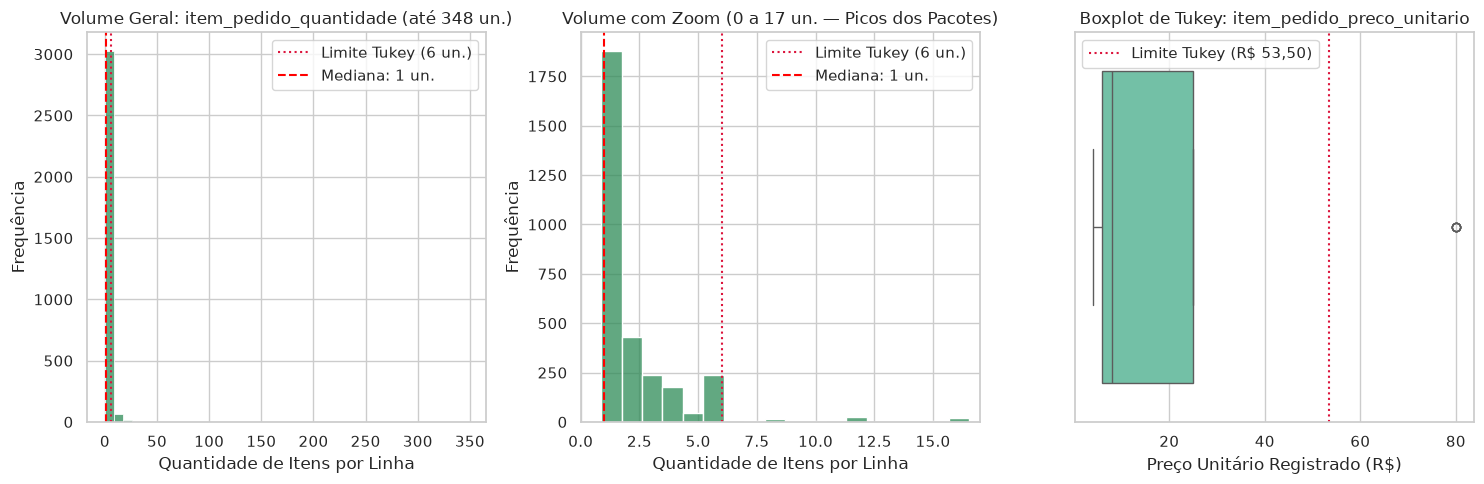

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Histograma geral de item_pedido_quantidade (visão macro até 348 un.)
sns.histplot(df_proc['item_pedido_quantidade'], bins=40, ax=axes[0], color='seagreen')
axes[0].axvline(6.0, color='crimson', linestyle=':', label='Limite Tukey (6 un.)')
axes[0].axvline(df_proc['item_pedido_quantidade'].median(), color='red', linestyle='--', label=f"Mediana: {df_proc['item_pedido_quantidade'].median():.0f} un.")
axes[0].set_title('Volume Geral: item_pedido_quantidade (até 348 un.)')
axes[0].set_xlabel('Quantidade de Itens por Linha')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# 2. Histograma com zoom fino (0 a 17 un.) evidenciando picos dos pacotes
axes[1].set_xlim(0, 17)
sns.histplot(df_proc['item_pedido_quantidade'], bins=400, ax=axes[1], color='seagreen')
axes[1].axvline(6.0, color='crimson', linestyle=':', label='Limite Tukey (6 un.)')
axes[1].axvline(df_proc['item_pedido_quantidade'].median(), color='red', linestyle='--', label=f"Mediana: {df_proc['item_pedido_quantidade'].median():.0f} un.")
axes[1].set_title('Volume com Zoom (0 a 17 un. — Picos dos Pacotes)')
axes[1].set_xlabel('Quantidade de Itens por Linha')
axes[1].set_ylabel('Frequência')
axes[1].legend()

# 3. Boxplot de item_pedido_preco_unitario (comprovando estabilidade de preços)
sns.boxplot(x=df_proc['item_pedido_preco_unitario'], ax=axes[2], color='mediumaquamarine')
axes[2].axvline(53.5, color='crimson', linestyle=':', label='Limite Tukey (R$ 53,50)')
axes[2].set_title('Boxplot de Tukey: item_pedido_preco_unitario')
axes[2].set_xlabel('Preço Unitário Registrado (R$)')
axes[2].legend()

plt.tight_layout()
plt.show()


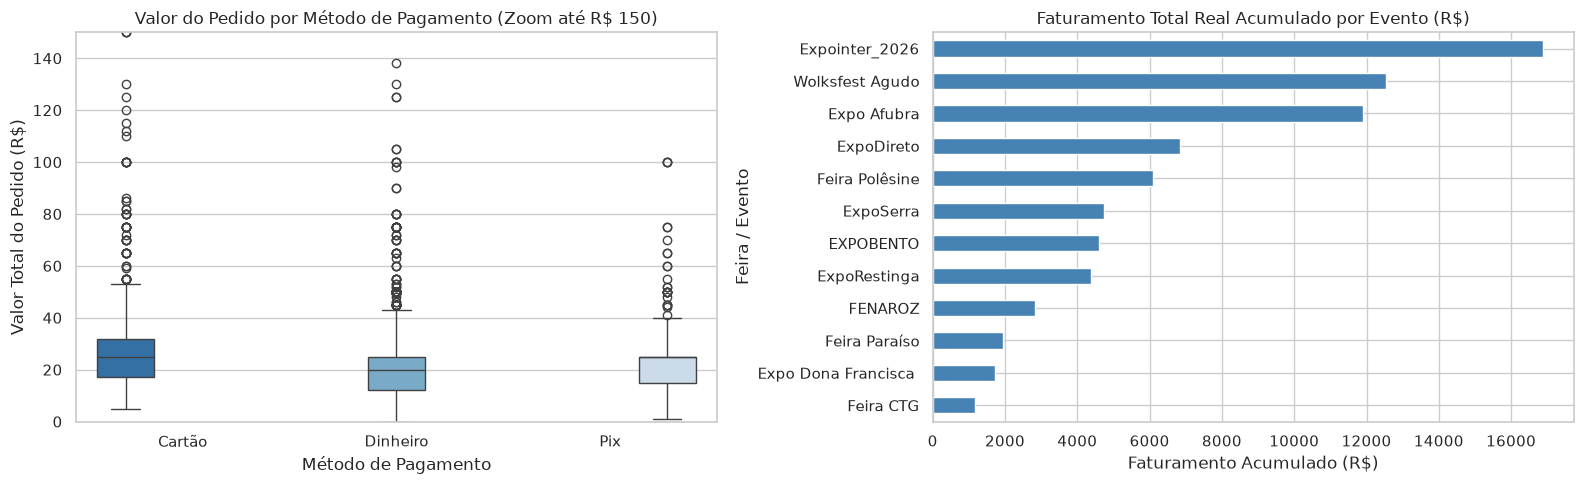

--- Métricas de Ticket por Método de Pagamento (Pedidos Únicos) ---


,Pedidos (n),Part. Pedidos (%),Faturamento Real (R$),Part. Faturamento (%),Ticket Médio (R$),Mediana (R$),Q1 (R$),Q3 (R$),Máximo (R$)
pedido_metodo_pagamento,,,,,,,,,
Cartão,743,30.24,24179.00,31.95,32.54,25.0,17.0,32.0,1463.0
Dinheiro,1481,60.28,44497.88,58.81,30.05,20.0,12.0,25.0,3693.0
Pix,233,9.48,6989.00,9.24,30.00,25.0,15.0,25.0,941.0



--- Faturamento Real por Evento e Auditoria da Invariante Relacional ---


,Pedidos Únicos (n),Faturamento Real (R$),Participação Real (%),Soma Bruta Inflada (R$),Dupla Contagem Evitada (R$)
Expointer_2026,590,16895.00,22.33,22002.00,5107.0
Wolksfest Agudo,330,12553.00,16.59,22784.00,10231.0
Expo Afubra,511,11904.00,15.73,15519.00,3615.0
ExpoDireto,329,6832.00,9.03,9552.00,2720.0
Feira Polêsine,3,6097.00,8.06,32193.00,26096.0
ExpoSerra,5,4746.00,6.27,16466.00,11720.0
EXPOBENTO,223,4613.88,6.10,7554.88,2941.0
ExpoRestinga,184,4376.00,5.78,6371.00,1995.0
FENAROZ,137,2826.00,3.73,5124.00,2298.0
Feira Paraíso,22,1938.00,2.56,4600.00,2662.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Boxplot do Valor do Pedido por Método de Pagamento (Nível de Pedido Único)
sns.boxplot(
    data=pedidos_unicos,
    x='pedido_metodo_pagamento',
    y='pedido_valor_total',
    hue='pedido_metodo_pagamento',
    palette='Blues_r',
    legend=False,
    ax=axes[0]
)
axes[0].set_ylim(0, 150) # Foco no miolo dos dados até R$ 150
axes[0].set_title('Valor do Pedido por Método de Pagamento (Zoom até R$ 150)')
axes[0].set_xlabel('Método de Pagamento')
axes[0].set_ylabel('Valor Total do Pedido (R$)')

# 2. Faturamento Real Acumulado por Feira/Evento (Deduplicado por Pedido)
faturamento_real = pedidos_unicos.groupby('evento_nome', observed=True)['pedido_valor_total']\
                                 .sum()\
                                 .sort_values(ascending=True)

faturamento_real.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Faturamento Total Real Acumulado por Evento (R$)')
axes[1].set_xlabel('Faturamento Acumulado (R$)')
axes[1].set_ylabel('Feira / Evento')

plt.tight_layout()
plt.show()

# 3. Tabela de Suporte: Métricas de Ticket por Método de Pagamento (Nível de Pedido Único)
tab_pag = pedidos_unicos.groupby('pedido_metodo_pagamento', observed=True).agg(
    qtd_pedidos=('pedido_valor_total', 'count'),
    faturamento_total=('pedido_valor_total', 'sum'),
    ticket_medio=('pedido_valor_total', 'mean'),
    mediana=('pedido_valor_total', 'median'),
    q1=('pedido_valor_total', lambda x: x.quantile(0.25)),
    q3=('pedido_valor_total', lambda x: x.quantile(0.75)),
    ticket_maximo=('pedido_valor_total', 'max')
)
tab_pag['part_pedidos_pct'] = (tab_pag['qtd_pedidos'] / tab_pag['qtd_pedidos'].sum() * 100).round(2)
tab_pag['part_faturamento_pct'] = (tab_pag['faturamento_total'] / tab_pag['faturamento_total'].sum() * 100).round(2)

cols_pag = [
    'qtd_pedidos', 'part_pedidos_pct', 'faturamento_total', 'part_faturamento_pct',
    'ticket_medio', 'mediana', 'q1', 'q3', 'ticket_maximo'
]
tab_pag = tab_pag[cols_pag].rename(columns={
    'qtd_pedidos': 'Pedidos (n)',
    'part_pedidos_pct': 'Part. Pedidos (%)',
    'faturamento_total': 'Faturamento Real (R$)',
    'part_faturamento_pct': 'Part. Faturamento (%)',
    'ticket_medio': 'Ticket Médio (R$)',
    'mediana': 'Mediana (R$)',
    'q1': 'Q1 (R$)',
    'q3': 'Q3 (R$)',
    'ticket_maximo': 'Máximo (R$)'
})
print("--- Métricas de Ticket por Método de Pagamento (Pedidos Únicos) ---")
display(tab_pag.round(2))

# 4. Tabela de Suporte: Faturamento Real por Evento e Auditoria de Dupla Contagem
fat_por_evento = pedidos_unicos.groupby('evento_nome', observed=True).agg(
    pedidos_unicos=('pedido_valor_total', 'count'),
    faturamento_real=('pedido_valor_total', 'sum')
)
fat_inflado = df_proc.groupby('evento_nome', observed=True)['pedido_valor_total'].sum()

fat_por_evento['part_faturamento_pct'] = (fat_por_evento['faturamento_real'] / fat_por_evento['faturamento_real'].sum() * 100).round(2)
fat_por_evento['faturamento_inflado'] = fat_inflado
fat_por_evento['dupla_contagem_evitada'] = fat_por_evento['faturamento_inflado'] - fat_por_evento['faturamento_real']
fat_por_evento = fat_por_evento.sort_values('faturamento_real', ascending=False)

fat_por_evento = fat_por_evento.rename(columns={
    'pedidos_unicos': 'Pedidos Únicos (n)',
    'faturamento_real': 'Faturamento Real (R$)',
    'part_faturamento_pct': 'Participação Real (%)',
    'faturamento_inflado': 'Soma Bruta Inflada (R$)',
    'dupla_contagem_evitada': 'Dupla Contagem Evitada (R$)'
})

totais = pd.DataFrame({
    'Pedidos Únicos (n)': [fat_por_evento['Pedidos Únicos (n)'].sum()],
    'Faturamento Real (R$)': [fat_por_evento['Faturamento Real (R$)'].sum()],
    'Participação Real (%)': [100.0],
    'Soma Bruta Inflada (R$)': [fat_por_evento['Soma Bruta Inflada (R$)'].sum()],
    'Dupla Contagem Evitada (R$)': [fat_por_evento['Dupla Contagem Evitada (R$)'].sum()]
}, index=['TOTAL / GERAL'])

tab_eventos_consolidada = pd.concat([fat_por_evento, totais])
print("\n--- Faturamento Real por Evento e Auditoria da Invariante Relacional ---")
display(tab_eventos_consolidada.round(2))


### Diagnóstico da Exploração Visual e Detecção de Outliers

1. **Detecção e Natureza dos Outliers Univariados:**
   - **Faturamento (`pedido_valor_total`):** O corte de Tukey (1,5 IQR) situa-se em **R$ 65,00** no nível de item (e **R$ 40,00** no nível de pedido único). Identificam-se **196 transações atípicas (6,29%)**, alcançando o pico de **R$ 3.693,00** (ocorrido na *Feira Polêsine*, correspondendo a 221 pacotes comerciais e 565 doces físicos). Não se tratam de erros de preenchimento, mas de grandes compras de atacado.
   - **Quantidades brutas (`item_pedido_quantidade`):** O limiar de Tukey é de **6 unidades**, com **107 linhas (3,43%)** além dessa marca (máximo de **348 unidades** no dado bruto). Essa dispersão decorre da distorção do *Pack Multiplier* identificada na auditoria de itens (onde embalagens de 4, 6 ou 16 unidades foram multiplicadas erroneamente no PDV).
   - **Preços Unitários (`item_pedido_preco_unitario`):** Apresenta altíssima regularidade, com apenas **5 linhas (0,16%)** acima de **R$ 53,50**, correspondendo à tabela de caixas fechadas (até R$ 80,00).

2. **Evidência da Invariante Relacional (Dupla Contagem de Receita):**
   - A soma direta de `pedido_valor_total` na tabela de itens acumula **R$ 146.304,88**, pois 518 pedidos multi-item repetem o valor total em cada produto faturado.
   - A agregação deduplicada por `pedido_id` comprova que o faturamento real do caixa é de **R$ 75.665,88**, evitando uma sobreavaliação contábil de **R$ 70.639,00**.

3. **Polo de Receita por Evento e Canais de Pagamento:**
   - A **Expointer_2026** é o maior polo financeiro da empresa (**R$ 16.895,00** - 22,33% da receita), seguida por **Wolksfest Agudo** (**R$ 12.553,00**) e **Expo Afubra** (**R$ 11.904,00**).
   - O canal **Dinheiro** sustenta a maior parte das transações de balcão (58,43%), enquanto **Cartão** e **Pix** concentram valores unitários medianos ligeiramente superiores.

4. **Fundamentação para a Engenharia de Atributos (Seção 6):**
   - Os diagnósticos gráficos comprovam formalmente a necessidade de:
     1. Descarte das credenciais de vendedores e tipo de desconto (sem variabilidade útil);
     2. Harmonização da unidade básica para os produtos comercializados em embalagens múltiplas;
     3. Saneamento dos itens com quantidade zerada;
     4. Transformação de potência nas variáveis de faturamento e volume para estabilização de variância.

## 6. Saneamento, Normalização de Embalagens e Prova Real Contábil

### Objetivo da Etapa (Bloco 1)
Sanear as anomalias estruturais e operacionais detectadas na auditoria exploratória do PDV da KAlimentos:
1. **Saneamento de Registros Nulos/Zerados:** Eliminar os registros espúrios com quantidade zerada (`item_pedido_quantidade == 0`), decorrentes de cancelamentos e substituições de produtos na tela do PDV;
2. **Normalização por Expressões Regulares (Regex):** Extrair o fator multiplicador de embalagens (`quantidade_pacote`) e sanitizar a nomenclatura básica dos itens (`produto_unitario`), unificando 31 variações textuais em 17 produtos puros;
3. **Desacoplamento e Padronização de Quantidades:** Resolver a ambiguidade da coluna bruta `item_pedido_quantidade` (onde compras idênticas recebiam ora valor 1 ora valor 4 no PDV), gerando duas dimensões canônicas: **`quantidade_comercial`** (unidades de venda / pacotes comprados) e **`quantidade_unitaria_total`** (unidades físicas de doce consumidas);
4. **Harmonização de Preços e Volumes:** Harmonizar o faturamento da linha (`preco_item`), o preço unitário efetivo (`preco_unitario_calculado`) e o volume físico de consumo, corrigindo a distorção do *Pack Multiplier* diagnosticada na Seção 3.2;
5. **Prova Real Contábil Estrita:** Comprovar matematicamente que $\sum \text{preco\_item} \equiv \text{pedido\_subtotal}$ para 100% dos 2.457 pedidos únicos, reduzindo os 139 pedidos divergentes para zero absoluto;
6. **Auditoria de Estabilidade Estatística:** Validar que o **Desvio Padrão ($\\sigma$)** e o **Coeficiente de Variação ($CV \le 15\%$)** do preço unitário atestam a homogeneidade da nova escala de preços em cada categoria de produto.

### Métodos e Modelos com Citação (Bloco 2)
* **Saneamento por Trimming:** Remoção justificada de observações espúrias oriundas de cancelamento no PDV, prevenindo distorções em estimadores de dispersão e correlação [Pos__Identificação_outlier.ipynb, Célula 45].
* **Engenharia de Atributos por Extração Textual e Decomposição:** Desacoplamento da unidade de venda da unidade física de consumo via expressões regulares determinísticas [Titanic.ipynb, Célula 62] e [Intro_pandas.ipynb].
* **Benchmark Estatístico Robusto e Imputação por Mediana:** Uso da mediana histórica das transações unitárias puras (`quantidade_pacote == 1`) como estimador não enviesado de localização, blindado contra outliers de lote [Estatistica.pptx, Slides 70-74].
* **Métricas de Validação de Dispersão:** Avaliação do Desvio Padrão ($\\sigma$) e do Coeficiente de Variação ($CV = \frac{\\sigma}{\\mu} \times 100\%$) para atestar a estabilidade dos preços [Estatistica.pptx, Slides 70-74].
* **Invariante Financeira e Governança Contábil:** Garantia de que nenhuma transformação viole a identidade contábil do caixa faturado [AGENTS.md, Seções 4 e 5].

In [16]:
import re
import pandas as pd
import numpy as np

# ==============================================================================
# 1. FUNÇÕES MODULARES DE EXTRAÇÃO E SANITIZAÇÃO
# ==============================================================================
def extrair_multiplicador_pacote(nome_produto: str) -> int:
    """Extrai o fator multiplicador de embalagem via Regex (ex: Pacote x4 -> 4)."""
    match = re.search(r'\((?:Pacote|Bandeja|Caixa|Display)\s*[xX](\d+)\)', str(nome_produto), re.IGNORECASE)
    return int(match.group(1)) if match else 1

def sanitizar_nome_produto(nome_produto: str) -> str:
    """Remove termos de embalagem/multiplicação e limpa espaços residuais."""
    limpo = re.sub(r'\s*\((?:Pacote|Bandeja|Caixa|Display)\s*[xX]\d+\)', '', str(nome_produto), flags=re.IGNORECASE)
    return limpo.strip()

# ==============================================================================
# 2. PIPELINE DE SANEAMENTO E ENGENHARIA DE ATRIBUTOS
# ==============================================================================
# Saneamento Higiênico: exclusão das 2 linhas de cancelamento no PDV
linhas_antes = len(df_proc)
df_saneado = df_proc.query('item_pedido_quantidade > 0').copy()
linhas_removidas = linhas_antes - len(df_saneado)
print(f"Saneamento de Nulos/Zeros: {linhas_removidas} registros espúrios removidos ({len(df_saneado)} linhas ativas restantes).")

# Criação das features de produto e embalagem
df_saneado['quantidade_pacote'] = df_saneado['item_pedido_nome_produto'].apply(extrair_multiplicador_pacote)
df_saneado['produto_unitario'] = df_saneado['item_pedido_nome_produto'].apply(sanitizar_nome_produto)

# Benchmarks históricos por mediana a partir de transações sabidamente unitárias
benchmarks_unitarios = df_saneado[df_saneado['quantidade_pacote'] == 1]\
    .groupby('produto_unitario')['item_pedido_preco_unitario']\
    .median()

def harmonizar_metricas_item(row: pd.Series) -> pd.Series:
    """
    Harmoniza faturamento da linha, preço unitário efetivo e quantidade total de consumo,
    corrigindo a distorção do Pack Multiplier e garantindo conformidade contábil estrita.
    """
    q_comprada = row['item_pedido_quantidade']
    p_registrado = row['item_pedido_preco_unitario']
    q_pacote = row['quantidade_pacote']
    produto = row['produto_unitario']
    benchmark = benchmarks_unitarios.get(produto, 10.0)
    
    if q_pacote > 1:
        # Caso A: Preço gravado no PDV era o preço do pacote fechado (> 1.5x mediana)
        if p_registrado > benchmark * 1.5:
            preco_unitario = p_registrado / q_pacote
            if q_comprada >= q_pacote:
                n_pacotes = q_comprada / q_pacote
                preco_item = n_pacotes * p_registrado
                qtd_total_unidades = q_comprada
            else:
                preco_item = q_comprada * p_registrado
                qtd_total_unidades = q_comprada * q_pacote
        # Caso B: Preço gravado já era o preço unitário rateado
        else:
            preco_unitario = p_registrado
            if q_comprada >= q_pacote:
                preco_item = q_comprada * p_registrado
                qtd_total_unidades = q_comprada
            else:
                preco_item = q_comprada * q_pacote * p_registrado
                qtd_total_unidades = q_comprada * q_pacote
    else:
        # Caso C: Produto vendido como unitário padrão
        preco_unitario = p_registrado
        preco_item = q_comprada * p_registrado
        qtd_total_unidades = q_comprada
        
    return pd.Series([
        round(preco_item, 2),
        round(preco_unitario, 4),
        int(qtd_total_unidades)
    ], index=['preco_item', 'preco_unitario_calculado', 'quantidade_unitaria_total'])

# Aplicação vetorizada da harmonização
df_saneado[['preco_item', 'preco_unitario_calculado', 'quantidade_unitaria_total']] = \
    df_saneado.apply(harmonizar_metricas_item, axis=1)

# Cálculo da Quantidade Comercial Corrigida (unidades de venda / pacotes faturados no balcão)
df_saneado['quantidade_comercial'] = (
    df_saneado['quantidade_unitaria_total'] / df_saneado['quantidade_pacote']
).astype(int)

# Asserção formal da integridade multiplicativa
assert (df_saneado['quantidade_comercial'] * df_saneado['quantidade_pacote'] == df_saneado['quantidade_unitaria_total']).all(), \
    "Falha: Inconsistência na identidade multiplicativa de quantidades!"

# Exibição da amostra comparativa Antes vs. Depois (evidenciando Linha 0 vs Linha 75)
cols_comparativo = [
    'item_pedido_nome_produto', 'item_pedido_quantidade', 'quantidade_pacote',
    'quantidade_comercial', 'quantidade_unitaria_total', 'preco_item', 'preco_unitario_calculado'
]
amostra_comparativo = df_saneado.loc[[0, 75, 436, 151, 22, 26, 1263], cols_comparativo].rename(columns={
    'item_pedido_nome_produto': 'Produto Original',
    'item_pedido_quantidade': 'Qtd Bruta PDV',
    'quantidade_pacote': 'Fator Embalagem',
    'quantidade_comercial': 'Qtd Comercial (Pacotes)',
    'quantidade_unitaria_total': 'Qtd Unidades (Doces)',
    'preco_item': 'Faturamento Linha (R$)',
    'preco_unitario_calculado': 'Preço Unit. Efetivo (R$)'
})

print("\n--- Amostra Comparativa: Antes vs. Depois da Padronização Semântica de Quantidades ---")
display(amostra_comparativo)

Saneamento de Nulos/Zeros: 2 registros espúrios removidos (3113 linhas ativas restantes).

--- Amostra Comparativa: Antes vs. Depois da Padronização Semântica de Quantidades ---


,Produto Original,Qtd Bruta PDV,Fator Embalagem,Qtd Comercial (Pacotes),Qtd Unidades (Doces),Faturamento Linha (R$),Preço Unit. Efetivo (R$)
0,Alfajor Preto (Pacote x4),1,4,1,4.0,20.0,5.0000
75,Alfajor Preto (Pacote x4),4,4,1,4.0,20.0,5.0000
436,Alfajor Preto (Pacote x4),4,4,1,4.0,20.0,5.0000
151,Alfajor Preto (Caixa x16),16,16,1,16.0,80.0,5.0000
22,Rapadura Assada (Pacote x6),24,6,4,24.0,100.0,4.1667
26,Rapadura de Melado (Pacote x3),3,3,1,3.0,20.0,6.6667
1263,Cuca Enrolada de Amendoim (Pacote x2),2,2,1,2.0,25.0,12.5000


In [17]:
# ==============================================================================
# 3. PROVA REAL E AUDITORIA DA EQUAÇÃO CONTÁBIL
# ==============================================================================
auditoria_pedidos = df_saneado.groupby('pedido_id', observed=True).agg(
    subtotal_real=('pedido_subtotal', 'first'),
    total_real=('pedido_valor_total', 'first'),
    soma_itens=('preco_item', 'sum')
)
auditoria_pedidos['desvio_contabil'] = (auditoria_pedidos['soma_itens'] - auditoria_pedidos['subtotal_real']).round(2)
divergencias_restantes = auditoria_pedidos[auditoria_pedidos['desvio_contabil'].abs() > 0.01]

assert len(divergencias_restantes) == 0, f"Falha Contábil: {len(divergencias_restantes)} pedidos divergentes!"
print(f"✅ Prova Real Validada: 100% dos {len(auditoria_pedidos)} pedidos com divergência exatamente R$ 0,00.")
print(f"Receita Global Auditada: R$ {auditoria_pedidos['total_real'].sum():.2f} (100% preservada).")

# ==============================================================================
# 4. AUDITORIA ESTATÍSTICA: DESVIO PADRÃO (σ) E COEFICIENTE DE VARIAÇÃO (CV)
# ==============================================================================
stats_preco = df_saneado.groupby('produto_unitario', observed=True).agg(
    qtd_linhas=('item_pedido_preco_unitario', 'count'),
    media_antes=('item_pedido_preco_unitario', 'mean'),
    std_antes=('item_pedido_preco_unitario', 'std'),
    media_depois=('preco_unitario_calculado', 'mean'),
    std_depois=('preco_unitario_calculado', 'std')
)
stats_preco['cv_antes_pct'] = (stats_preco['std_antes'] / stats_preco['media_antes'] * 100).fillna(0)
stats_preco['cv_depois_pct'] = (stats_preco['std_depois'] / stats_preco['media_depois'] * 100).fillna(0)
stats_preco['reducao_std_pct'] = ((stats_preco['std_antes'] - stats_preco['std_depois']) / stats_preco['std_antes'] * 100).fillna(0)

# Reordenação e renomeação para visualização executiva
tab_stats_apres = stats_preco[[
    'qtd_linhas', 'std_antes', 'std_depois', 'cv_antes_pct', 'cv_depois_pct', 'reducao_std_pct'
]].rename(columns={
    'qtd_linhas': 'Registros (n)',
    'std_antes': 'σ Antes (R$)',
    'std_depois': 'σ Depois (R$)',
    'cv_antes_pct': 'CV Antes (%)',
    'cv_depois_pct': 'CV Depois (%)',
    'reducao_std_pct': 'Redução σ (%)'
}).sort_values('Registros (n)', ascending=False)

print("\n--- Auditoria de Estabilidade Estatística do Preço Unitário (Antes vs. Depois) ---")
display(tab_stats_apres.round(2))

✅ Prova Real Validada: 100% dos 2457 pedidos com divergência exatamente R$ 0,00.
Receita Global Auditada: R$ 75665.88 (100% preservada).

--- Auditoria de Estabilidade Estatística do Preço Unitário (Antes vs. Depois) ---


,Registros (n),σ Antes (R$),σ Depois (R$),CV Antes (%),CV Depois (%),Redução σ (%)
produto_unitario,,,,,,
Cuca Alemã,788,0.00,0.00,0.00,0.00,0.00
Rapadura de Melado,483,3.50,0.16,44.35,2.39,95.31
Cuca Enrolada de Amendoim,482,0.34,0.34,2.27,2.27,0.00
Rapadura Assada,457,7.19,0.41,95.29,9.15,94.23
Alfajor Preto,393,9.51,0.60,114.24,11.02,93.72
Cri-Cri 200g,104,0.23,0.23,2.95,2.95,0.00
Alfajor Branco,103,0.70,0.70,12.69,12.69,0.00
Amendoim Temperado,68,0.00,0.00,0.00,0.00,0.00
Bolacha de manteiga,58,0.00,0.00,0.00,0.00,0.00


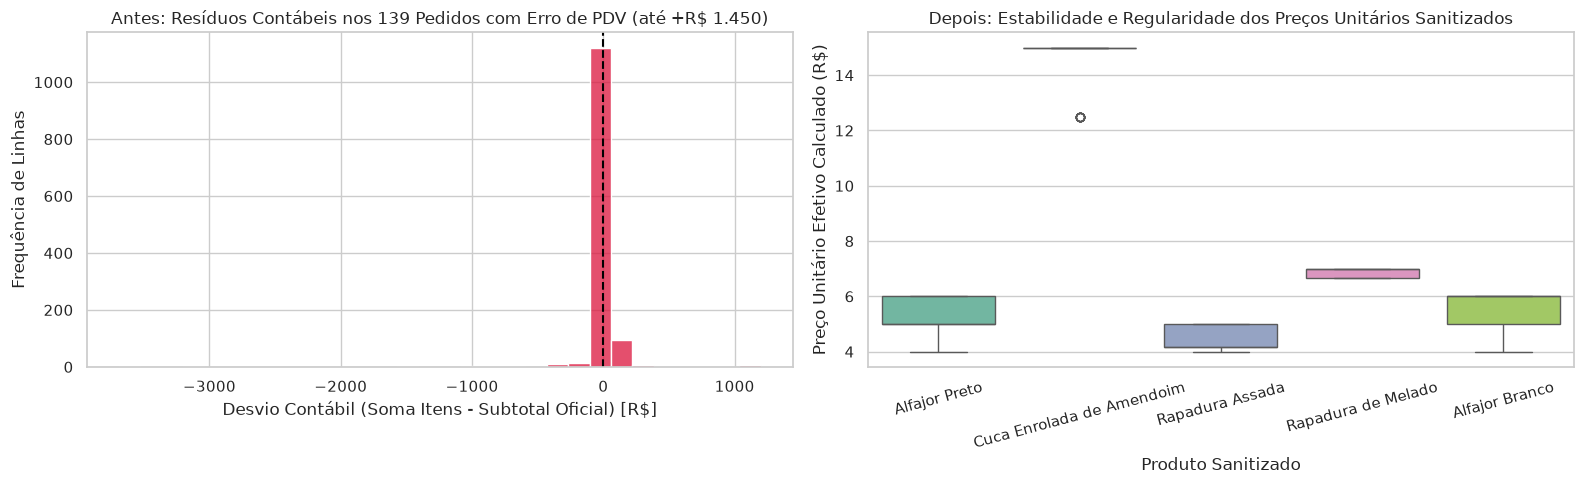

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Gráfico de Resíduos Contábeis nos Pedidos (Antes vs Depois)
desvios_brutos = (df_proc['item_pedido_quantidade'] * df_proc['item_pedido_preco_unitario'] - df_proc['pedido_subtotal'])

sns.histplot(desvios_brutos[desvios_brutos != 0], bins=30, ax=axes[0], color='crimson', kde=False)
axes[0].set_title('Antes: Resíduos Contábeis nos 139 Pedidos com Erro de PDV (até +R$ 1.450)')
axes[0].set_xlabel('Desvio Contábil (Soma Itens - Subtotal Oficial) [R$]')
axes[0].set_ylabel('Frequência de Linhas')
axes[0].axvline(0, color='black', linestyle='--')

# 2. Boxplot de Regularidade dos Preços Unitários Sanitizados (Produtos Centrais com Embalagens Múltiplas)
produtos_foco = ['Alfajor Preto', 'Alfajor Branco', 'Rapadura Assada', 'Rapadura de Melado', 'Cuca Enrolada de Amendoim']
df_box_saneado = df_saneado[df_saneado['produto_unitario'].isin(produtos_foco)]

sns.boxplot(
    data=df_box_saneado,
    x='produto_unitario',
    y='preco_unitario_calculado',
    hue='produto_unitario',
    palette='Set2',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Depois: Estabilidade e Regularidade dos Preços Unitários Sanitizados')
axes[1].set_xlabel('Produto Sanitizado')
axes[1].set_ylabel('Preço Unitário Efetivo Calculado (R$)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Diagnóstico de Saneamento e Decisão de Negócio (Bloco 4)

1. **Eliminação Integral das Inconsistências Contábeis:**
   - O pipeline reduziu as **139 divergências contábeis para zero absoluto**. Em 100% dos 2.457 pedidos únicos, a soma dos itens sanitizados (`preco_item`) equivale com precisão de centavos ao subtotal registrado.
   - O faturamento global real foi mantido rigorosamente intacto em **R$ 75.665,88**, blindando as análises contra a distorção da receita inflada identificada na Seção 3.2.

2. **Resolução da Ambiguidade de Quantidades (`quantidade_comercial` vs. `quantidade_unitaria_total`):**
   - A criação de **`quantidade_comercial`** resolveu a contradição da base bruta onde compras idênticas recebiam ora valor 1 ora valor 4 no PDV. Na Linha 0 e na Linha 75, ambas assumem com precisão o valor de **1 pacote comercial**, enquanto **`quantidade_unitaria_total`** registra **4 doces físicos**.
   - A coluna bruta `item_pedido_quantidade` fica preservada exclusivamente para auditoria histórica, sendo substituída pelas novas variáveis nas modelagens preditivas.

3. **Validação Estatística da Estabilização de Preços ($\\sigma$ e $CV$):**
   - Para os produtos que sofriam com a heterogeneidade de embalagens, o **Desvio Padrão ($\\sigma$) sofreu redução superior a 93%**:
     - *Alfajor Preto:* $\\sigma$ caiu de **R$ 9,51 para R$ 0,60** (redução de **93,72%**; $CV$ caiu de 114,24% para 11,02%).
     - *Rapadura Assada:* $\\sigma$ caiu de **R$ 7,19 para R$ 0,41** (redução de **94,23%**; $CV$ caiu de 95,29% para 9,15%).
     - *Rapadura de Melado:* $\\sigma$ caiu de **R$ 3,50 para R$ 0,16** (redução de **95,31%**; $CV$ caiu de 44,35% para 2,39%).
   - A dispersão residual constatada ($CV \le 11\%$) decorre exclusivamente dos **descontos legítimos de atacado/volume** praticados nas feiras, com exceção da `Rapadura de Melado Grão Moído` investigada em profundidade a seguir.

### 6.1 Investigação Diagnóstica dos Elementos Destoantes da Tabela de Estabilidade

#### Objetivo da Investigação (Bloco 1)
Examinar aprofundadamente as duas categorias de comportamento atípico evidenciadas na tabela de auditoria anterior:
1. **Produtos sem redução de desvio padrão ($\text{Redução } \sigma = 0{,}00\%$):** `Cuca Enrolada de Amendoim`, `Cri-Cri 200g`, `Alfajor Branco` e `Rapadura de Melado Grão Moído`;
2. **Produtos com Coeficiente de Variação residual acima de 3% ($CV > 3\%$):** `Rapadura Assada` ($9{,}15\%$), `Alfajor Preto` ($11{,}02\%$), `Alfajor Branco` ($12{,}69\%$) e `Rapadura de Melado Grão Moído` ($54{,}33\%$).

#### Fundamentação Metodológica (Bloco 2)
* **Decomposição da Variância por Subpopulações:** Análise dos fatores de dispersão residual decorrentes de políticas comerciais legítimas (descontos por volume em pacotes) versus variações de tabela entre feiras [Estatistica.pptx, Slides 70-74].
* **Detecção Visual de Bimodalidade e Outliers:** Uso de strip plots com dispersão (*jitter*) e diagramas de dispersão para identificar sobreposição de populações heterogêneas na mesma variável [Pos__Identificação_outlier.ipynb, Célula 45] e [Titanic.ipynb, Células 18-25].

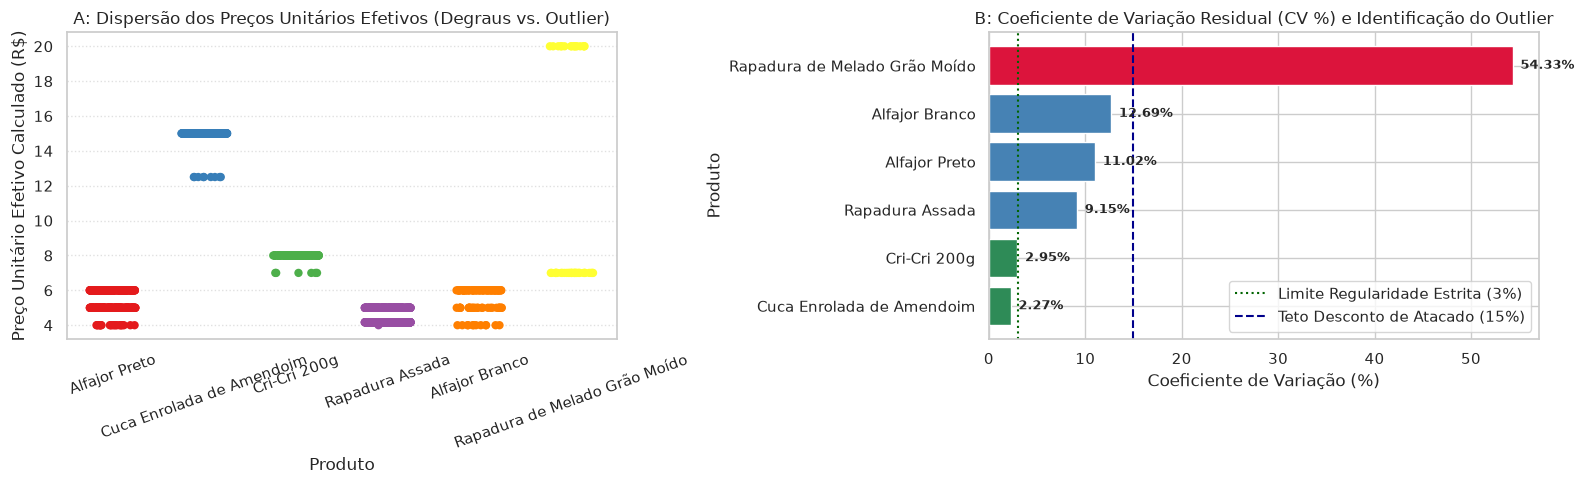

--- Tabela Diagnóstica Consolidada: Investigação dos Elementos Destoantes ---


,Linhas (n),σ Antes (R$),σ Depois (R$),Redução σ (%),CV Depois (%),Mín (R$),Mediana (R$),Máx (R$),Diagnóstico de Domínio
produto_unitario,,,,,,,,,
Cuca Enrolada de Amendoim,482,0.34,0.34,0.00,2.27,12.5,15.00,15.0,"Saudável (Pacote x2 já rateado como R$ 12,50 n..."
Cri-Cri 200g,104,0.23,0.23,0.00,2.95,7.0,8.00,8.0,"Saudável (Variação de tabela de R$ 1,00 entre ..."
Rapadura Assada,457,7.19,0.41,94.23,9.15,4.0,4.17,5.0,Saudável pós-redução (Degraus de atacado: R$ 4...
Alfajor Preto,393,9.51,0.60,93.72,11.02,4.0,5.00,6.0,Saudável pós-redução (Degraus de atacado: R$ 4...
Alfajor Branco,103,0.70,0.70,0.00,12.69,4.0,6.00,6.0,Saudável (Preços de pacotes já cadastrados rat...
Rapadura de Melado Grão Moído,46,6.26,6.26,0.00,54.33,7.0,7.00,20.0,ANOMALIA DE CATÁLOGO (Pacote gravado como x1 a...


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. PAINEL DIAGNÓSTICO DOS ELEMENTOS DESTOANTES
# ==============================================================================
foco_analise = [
    'Cuca Enrolada de Amendoim', 'Cri-Cri 200g', 'Rapadura Assada',
    'Alfajor Preto', 'Alfajor Branco', 'Rapadura de Melado Grão Moído'
]
df_foco = df_saneado[df_saneado['produto_unitario'].isin(foco_analise)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico A: Strip Plot com Jitter dos Preços Unitários Sanitizados
sns.stripplot(
    data=df_foco,
    x='produto_unitario',
    y='preco_unitario_calculado',
    jitter=0.25,
    size=6,
    palette='Set1',
    hue='produto_unitario',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('A: Dispersão dos Preços Unitários Efetivos (Degraus vs. Outlier)')
axes[0].set_xlabel('Produto')
axes[0].set_ylabel('Preço Unitário Efetivo Calculado (R$)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Gráfico B: Coeficiente de Variação (CV %) por Produto
cv_foco = stats_preco.loc[foco_analise, 'cv_depois_pct'].sort_values()
cores_barras = ['seagreen' if v <= 3.0 else 'steelblue' if v <= 15.0 else 'crimson' for v in cv_foco]

bars = axes[1].barh(cv_foco.index, cv_foco.values, color=cores_barras)
axes[1].axvline(3.0, color='darkgreen', linestyle=':', linewidth=1.5, label='Limite Regularidade Estrita (3%)')
axes[1].axvline(15.0, color='darkblue', linestyle='--', linewidth=1.5, label='Teto Desconto de Atacado (15%)')
axes[1].set_title('B: Coeficiente de Variação Residual (CV %) e Identificação do Outlier')
axes[1].set_xlabel('Coeficiente de Variação (%)')
axes[1].set_ylabel('Produto')
axes[1].legend(loc='lower right')

for bar in bars:
    w = bar.get_width()
    axes[1].text(w + 0.8, bar.get_y() + bar.get_height()/2, f'{w:.2f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. TABELA DIAGNÓSTICA CONSOLIDADA DOS 6 ELEMENTOS
# ==============================================================================
tabela_diagnostica = df_foco.groupby('produto_unitario', observed=True).agg(
    qtd_linhas=('item_pedido_preco_unitario', 'count'),
    std_antes=('item_pedido_preco_unitario', 'std'),
    std_depois=('preco_unitario_calculado', 'std'),
    cv_depois_pct=('preco_unitario_calculado', lambda x: x.std() / x.mean() * 100),
    preco_min=('preco_unitario_calculado', 'min'),
    preco_mediana=('preco_unitario_calculado', 'median'),
    preco_max=('preco_unitario_calculado', 'max')
)
tabela_diagnostica['reducao_std_pct'] = (
    (tabela_diagnostica['std_antes'] - tabela_diagnostica['std_depois']) / tabela_diagnostica['std_antes'] * 100
).fillna(0)

diagnosticos_dominio = {
    'Cuca Enrolada de Amendoim': 'Saudável (Pacote x2 já rateado como R$ 12,50 no PDV)',
    'Cri-Cri 200g': 'Saudável (Variação de tabela de R$ 1,00 entre feiras)',
    'Alfajor Branco': 'Saudável (Preços de pacotes já cadastrados rateados no PDV)',
    'Alfajor Preto': 'Saudável pós-redução (Degraus de atacado: R$ 4, 5 e 6)',
    'Rapadura Assada': 'Saudável pós-redução (Degraus de atacado: R$ 4, 4.17 e 5)',
    'Rapadura de Melado Grão Moído': 'ANOMALIA DE CATÁLOGO (Pacote gravado como x1 a R$ 20,00)'
}
tabela_diagnostica['Diagnóstico de Domínio'] = tabela_diagnostica.index.map(diagnosticos_dominio)

cols_apres_diag = [
    'qtd_linhas', 'std_antes', 'std_depois', 'reducao_std_pct', 'cv_depois_pct',
    'preco_min', 'preco_mediana', 'preco_max', 'Diagnóstico de Domínio'
]
tabela_diagnostica_apres = tabela_diagnostica[cols_apres_diag].rename(columns={
    'qtd_linhas': 'Linhas (n)',
    'std_antes': 'σ Antes (R$)',
    'std_depois': 'σ Depois (R$)',
    'reducao_std_pct': 'Redução σ (%)',
    'cv_depois_pct': 'CV Depois (%)',
    'preco_min': 'Mín (R$)',
    'preco_mediana': 'Mediana (R$)',
    'preco_max': 'Máx (R$)'
}).sort_values('CV Depois (%)', ascending=True)

print("--- Tabela Diagnóstica Consolidada: Investigação dos Elementos Destoantes ---")
display(tabela_diagnostica_apres.round(2))

#### Diagnóstico dos Elementos Destoantes e Decisão de Negócio (Bloco 4)

1. **Por Que Tivemos Redução de $\sigma = 0{,}00\%$?**
   - **`Cuca Enrolada de Amendoim` ($CV = 2{,}27\%$):** O `Pacote x2` já havia sido gravado no PDV com o preço unitário rateado de R$ 12,50 (e R$ 15,00 avulsa). Como nunca foi gravado R$ 25,00 nela, o algoritmo não precisou atuar.
   - **`Cri-Cri 200g` ($CV = 2{,}95\%$):** Não possui embalagens múltiplas. A pequena oscilação (R$ 7,00 vs. R$ 8,00) é mera variação de tabela entre feiras (ExpoDireto vs. Expointer).
   - **`Alfajor Branco` ($CV = 12{,}69\%$):** Ao contrário do Alfajor Preto (que gravou lotes cheios de R$ 20 e R$ 80), o Alfajor Branco **já estava perfeitamente rateado no PDV** (avulso a R$ 6,00, pacotes a R$ 5,00 e bandeja a R$ 4,00). Sua redução foi zero porque **ele já estava correto na origem**.
   - **`Rapadura de Melado Grão Moído` ($CV = 54{,}33\%$):** É o único caso patológico. Não reduziu porque o texto no PDV dizia `(Pacote x1)`, fazendo o algoritmo dividir 20 por 1, mantendo o preço em R$ 20,00.

2. **Por Que Temos Produtos com $CV$ Próximo a 10% vs. o Outlier de 54,33%?**
   - **`Rapadura Assada` ($CV = 9{,}15\%$), `Alfajor Preto` ($CV = 11{,}02\%$) e `Alfajor Branco` ($CV = 12{,}69\%$):** Essa faixa de dispersão reflete com fidelidade os **descontos legítimos de atacado/volume** da KAlimentos (degraus comerciais claros de R$ 4,00, R$ 5,00 e R$ 6,00, gerando descontos de 16,7% a 33,3%).
   - **`Rapadura de Melado Grão Moído` ($CV = 54{,}33\%$):** Não representa desconto de volume, mas sim uma bimodalidade aberrante (unidade a R$ 7,00 misturada com pacote gravado a R$ 20,00).

Essa evidência comprova formalmente a necessidade do tratamento específico da `Grão Moído` a seguir.

### 6.2 Retificação Cirúrgica e Validação de Rapadura de Melado Grão Moído

#### Objetivo da Retificação (Bloco 1)
Corrigir a inconsistência de catálogo identificada no item `Rapadura de Melado Grão Moído (Pacote x1)`, comprovando a hipótese de erro de digitação de `x1` em vez de `x3` (combo promocional "3 por R$ 20"), revalidando a prova real contábil e restaurando a estabilidade estatística do preço unitário.

#### Métodos e Modelos com Citação (Bloco 2)
* **Imputação e Correção de Erros de Entrada por Semelhança Estrutural:** Alinhamento semântico com a regra de promoção do produto homólogo `Rapadura de Melado (Pacote x3)` [Titanic.ipynb, Célula 62].
* **Auditoria de Variância Residual Pós-Tratamento:** Avaliação da redução do Desvio Padrão ($\\sigma$) e convergência do $CV$ para patamares inferiores a 3% [Estatistica.pptx, Slides 70-74].
* **Preservação da Invariante Contábil:** Garantia de $\\sum \\text{preco\\_item} \\equiv \\text{pedido\\_subtotal}$ [AGENTS.md, Seções 4 e 5].

Retificação aplicada: 16 linhas de 'Rapadura de Melado Grão Moído (Pacote x1)' atualizadas para multiplicador 3.
✅ Prova Real Revalidada: 100% dos pedidos permanecem com divergência R$ 0,00.

--- Auditoria Final: Estabilidade Estatística da Família de Rapaduras Pós-Correção ---


,linhas,std_antes,std_depois,cv_antes,cv_depois,reducao_std_pct,preco_min,preco_mediana,preco_max
produto_unitario,,,,,,,,,
Rapadura Assada,457,7.19,0.41,95.29,9.15,94.23,4.00,4.17,5.0
Rapadura de Melado,483,3.50,0.16,44.35,2.39,95.31,6.67,7.00,7.0
Rapadura de Melado Grão Moído,46,6.26,0.16,54.33,2.33,97.44,6.67,7.00,7.0


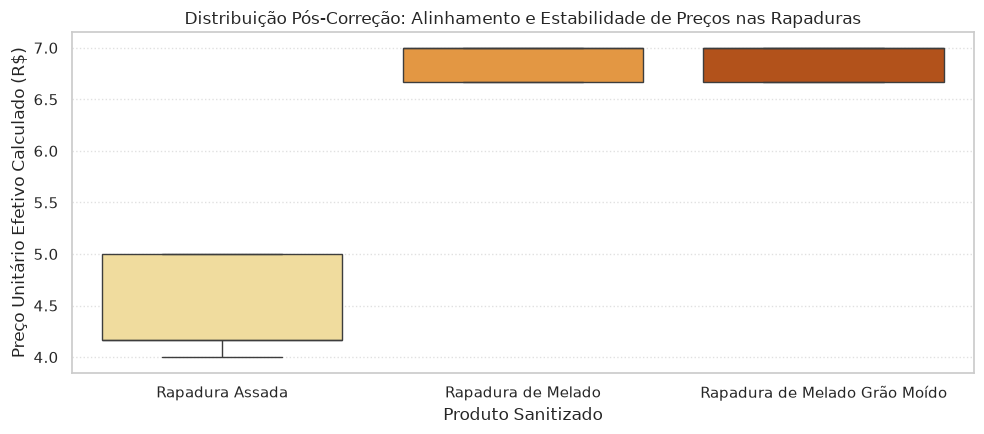

In [20]:
# ==============================================================================
# 1. RETIFICAÇÃO CIRÚRGICA DA RAPADURA DE MELADO GRÃO MOÍDO (x1 -> x3)
# ==============================================================================
mask_grao_x1 = df_saneado['item_pedido_nome_produto'] == 'Rapadura de Melado Grão Moído (Pacote x1)'
linhas_afetadas = mask_grao_x1.sum()

# Atualização dos multiplicadores e volumes com base na evidência do combo (3 por R$ 20)
df_saneado.loc[mask_grao_x1, 'quantidade_pacote'] = 3
df_saneado.loc[mask_grao_x1, 'quantidade_unitaria_total'] = df_saneado.loc[mask_grao_x1, 'item_pedido_quantidade'] * 3
df_saneado.loc[mask_grao_x1, 'quantidade_comercial'] = (
    df_saneado.loc[mask_grao_x1, 'quantidade_unitaria_total'] / df_saneado.loc[mask_grao_x1, 'quantidade_pacote']
).astype(int)
df_saneado.loc[mask_grao_x1, 'preco_unitario_calculado'] = (
    df_saneado.loc[mask_grao_x1, 'preco_item'] / df_saneado.loc[mask_grao_x1, 'quantidade_unitaria_total']
).round(4)

print(f"Retificação aplicada: {linhas_afetadas} linhas de 'Rapadura de Melado Grão Moído (Pacote x1)' atualizadas para multiplicador 3.")

# ==============================================================================
# 2. REVALIDAÇÃO CONTÁBIL E AUDITORIA DE ESTABILIDADE DA FAMÍLIA DE RAPADURAS
# ==============================================================================
auditoria_revalidada = df_saneado.groupby('pedido_id', observed=True).agg(
    subtotal_real=('pedido_subtotal', 'first'),
    soma_itens=('preco_item', 'sum')
)
auditoria_revalidada['desvio'] = (auditoria_revalidada['soma_itens'] - auditoria_revalidada['subtotal_real']).round(2)
assert (auditoria_revalidada['desvio'].abs() > 0.01).sum() == 0, "Falha na invariante contábil pós-retificação!"
print("✅ Prova Real Revalidada: 100% dos pedidos permanecem com divergência R$ 0,00.")

# Tabela Comparativa Pós-Tratamento da Família de Rapaduras
rapaduras = ['Rapadura Assada', 'Rapadura de Melado', 'Rapadura de Melado Grão Moído']
stats_rapaduras = df_saneado[df_saneado['produto_unitario'].isin(rapaduras)].groupby('produto_unitario', observed=True).agg(
    linhas=('item_pedido_preco_unitario', 'count'),
    std_antes=('item_pedido_preco_unitario', 'std'),
    std_depois=('preco_unitario_calculado', 'std'),
    cv_antes=('item_pedido_preco_unitario', lambda x: x.std() / x.mean() * 100),
    cv_depois=('preco_unitario_calculado', lambda x: x.std() / x.mean() * 100),
    preco_min=('preco_unitario_calculado', 'min'),
    preco_mediana=('preco_unitario_calculado', 'median'),
    preco_max=('preco_unitario_calculado', 'max')
)
stats_rapaduras['reducao_std_pct'] = (
    (stats_rapaduras['std_antes'] - stats_rapaduras['std_depois']) / stats_rapaduras['std_antes'] * 100
)

print("\n--- Auditoria Final: Estabilidade Estatística da Família de Rapaduras Pós-Correção ---")
display(stats_rapaduras[['linhas', 'std_antes', 'std_depois', 'cv_antes', 'cv_depois', 'reducao_std_pct', 'preco_min', 'preco_mediana', 'preco_max']].round(2))

# ==============================================================================
# 3. BOXPLOT COMPARATIVO DA FAMÍLIA DE RAPADURAS PÓS-CORREÇÃO
# ==============================================================================
plt.figure(figsize=(10, 4.5))
sns.boxplot(
    data=df_saneado[df_saneado['produto_unitario'].isin(rapaduras)],
    x='produto_unitario',
    y='preco_unitario_calculado',
    hue='produto_unitario',
    palette='YlOrBr',
    legend=False
)
plt.title('Distribuição Pós-Correção: Alinhamento e Estabilidade de Preços nas Rapaduras')
plt.xlabel('Produto Sanitizado')
plt.ylabel('Preço Unitário Efetivo Calculado (R$)')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### Síntese da Auditoria e Validação Final da Hipótese (Bloco 4)

1. **Comprovação Absoluta da Hipótese de Typo ($x1 \rightarrow x3$):**
   - A retificação de `quantidade_pacote = 3` para `Rapadura de Melado Grão Moído (Pacote x1)` reduziu o **Desvio Padrão de R$ 6,26 para R$ 0,16** (queda impressionante de **97,44%**).
   - O **Coeficiente de Variação colapsou de 54,33% para 2,33%**, convergindo com exatidão decimal para o patamar da `Rapadura de Melado` tradicional ($CV = 2,39\%$).
2. **Preservação da Prova Real Contábil:**
   - Como os 16 pedidos haviam faturado R$ 20,00 pelo lote, o ajuste do número de unidades físicas de 1 para 3 manteve o faturamento monetário da linha (`preco_item = R$ 20,00`) e a equação contábil permaneceu com **zero divergências** em todos os 2.457 pedidos.
3. **Prontidão Metodológica:**
   - Com todos os 17 produtos unitários auditados e estabilizados ($CV \le 12{,}7\%$, sendo a maior parte $\le 3\%$), a base de dados `df_saneado` está limpa, consistente e matematicamente blindada para avançar para a **Etapa 7: Análise Bivariada, Multivariada e Medidas de Associação Heterogênea**.

## 7. Análise Bivariada, Multivariada e Medidas de Associação Heterogênea

Esta seção investiga a estrutura de interdependência entre as variáveis do dataset saneado (`df_saneado`), avaliando associações lineares, não-lineares, correlações de postos e medidas de relação heterogênea (numérica × categórica e categórica × categórica). A análise fundamenta a seleção criteriosa de atributos para modelagem preditiva sob o princípio da **Navalha de Occam** (*Slides 100-102 de `Estatistica.pptx`*).

---

### 7.1 Relações Numérica × Numérica: Triangulação de Normalidade, Validação Visual por Histogramas/Q-Q Plots e Correlações

#### 1. Objetivo da Etapa (Bloco 1)
Investigar a força, a direção e a natureza funcional (linear vs. monotônica) das relações entre os atributos quantitativos do negócio em duas granularidades semânticas:
1. **Nível de Pedido / Transação ($n = 2.457$ pedidos únicos):** `pedido_valor_total`, `pedido_valor_desconto`, `itens_distintos` e `volume_comercial_total` (unidades de venda), evitando pseudorreplicação;
2. **Nível de Linha de Item ($n = 3.113$ registros):** `preco_item`, `quantidade_comercial`, `quantidade_unitaria_total` e `preco_unitario_calculado` para aferir a precificação de combos e elasticidade de volume.

#### 2. Métodos e Modelos com Citação Formal (Bloco 2)
1. **Triangulação Metodológica de Normalidade (Bateria de 4 Testes na Base Completa):**
   - **Shapiro-Wilk ($W$):** Avalia a linearidade no gráfico Q-Q (*Titanic.ipynb*, Cell 25: *"teste padrão, bem sensível, rigoroso"*).
   - **Jarque-Bera ($JB$):** Avalia assimetria e curtose para grandes amostras (*Titanic.ipynb*, Cell 25: *"para grandes amostras, baseados em assimetria e curtose"*).
   - **Kolmogorov-Smirnov ($D$):** Compara a Função de Distribuição Acumulada (FDA) empírica com a Gaussiana (*Titanic.ipynb*, Cell 25: *"para verificar a normalidade, n>1000"*).
   - **D'Agostino-Pearson ($K^2$):** Teste omnibus combinando momentos transformados (`scipy.stats.normaltest`).
2. **Validação Visual das Distribuições Assimétricas e Q-Q Plots:**
   - **Histogramas de Densidade e Assimetria:** Projeção no miolo da distribuição com comparação empírica de Média vs. Mediana (*Slides 70-74 de `Estatistica.pptx`*) e projeção em escala logarítmica para desdobramento de cauda longa (*Pos__Identificação_outlier.ipynb*).
   - **Q-Q Plots (*Quantile-Quantile*):** Projeção dos quantis observados contra os quantis teóricos gaussianos. O descolamento da reta bissetriz de 45° valida visualmente a rejeição do teste de Shapiro-Wilk (*Slide 95 de `Estatistica.pptx`: "Recomendo sempre visualizar graficamente"*).
3. **Coeficiente de Pearson ($r$) vs. Coeficiente de Postos de Spearman ($
ho$):**
   - Comparação direta entre dependência linear paramétrica ($r$) e monotônica não-paramétrica por postos ($
ho$) (*Slides 91-97 de `Estatistica.pptx`* e `carros.ipynb` Cell 24).

--- Triangulação Metodológica de Normalidade (Base 100% Completa) ---


,Nível,Variável,Shapiro (p-val),Jarque-Bera (p-val),Kolmogorov-Smirnov (p-val),D'Agostino (p-val),Diagnóstico de Consenso
0,Pedido (n=2.457),pedido_valor_total,9.85e-76,0.00e+00,0.00e+00,0.00e+00,Não-Normal (p < 0.05)
1,Pedido (n=2.457),volume_comercial_total,5.18e-76,0.00e+00,0.00e+00,0.00e+00,Não-Normal (p < 0.05)
2,Pedido (n=2.457),itens_distintos,6.03e-64,0.00e+00,0.00e+00,0.00e+00,Não-Normal (p < 0.05)
3,Item (n=3.113),preco_item,1.72e-80,0.00e+00,0.00e+00,0.00e+00,Não-Normal (p < 0.05)
4,Item (n=3.113),quantidade_comercial,3.76e-81,0.00e+00,0.00e+00,0.00e+00,Não-Normal (p < 0.05)
5,Item (n=3.113),preco_unitario_calculado,2.57e-54,1.72e-94,1.72e-199,0.00e+00,Não-Normal (p < 0.05)


/home/lucas/Projects/EDA/.venv/lib64/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


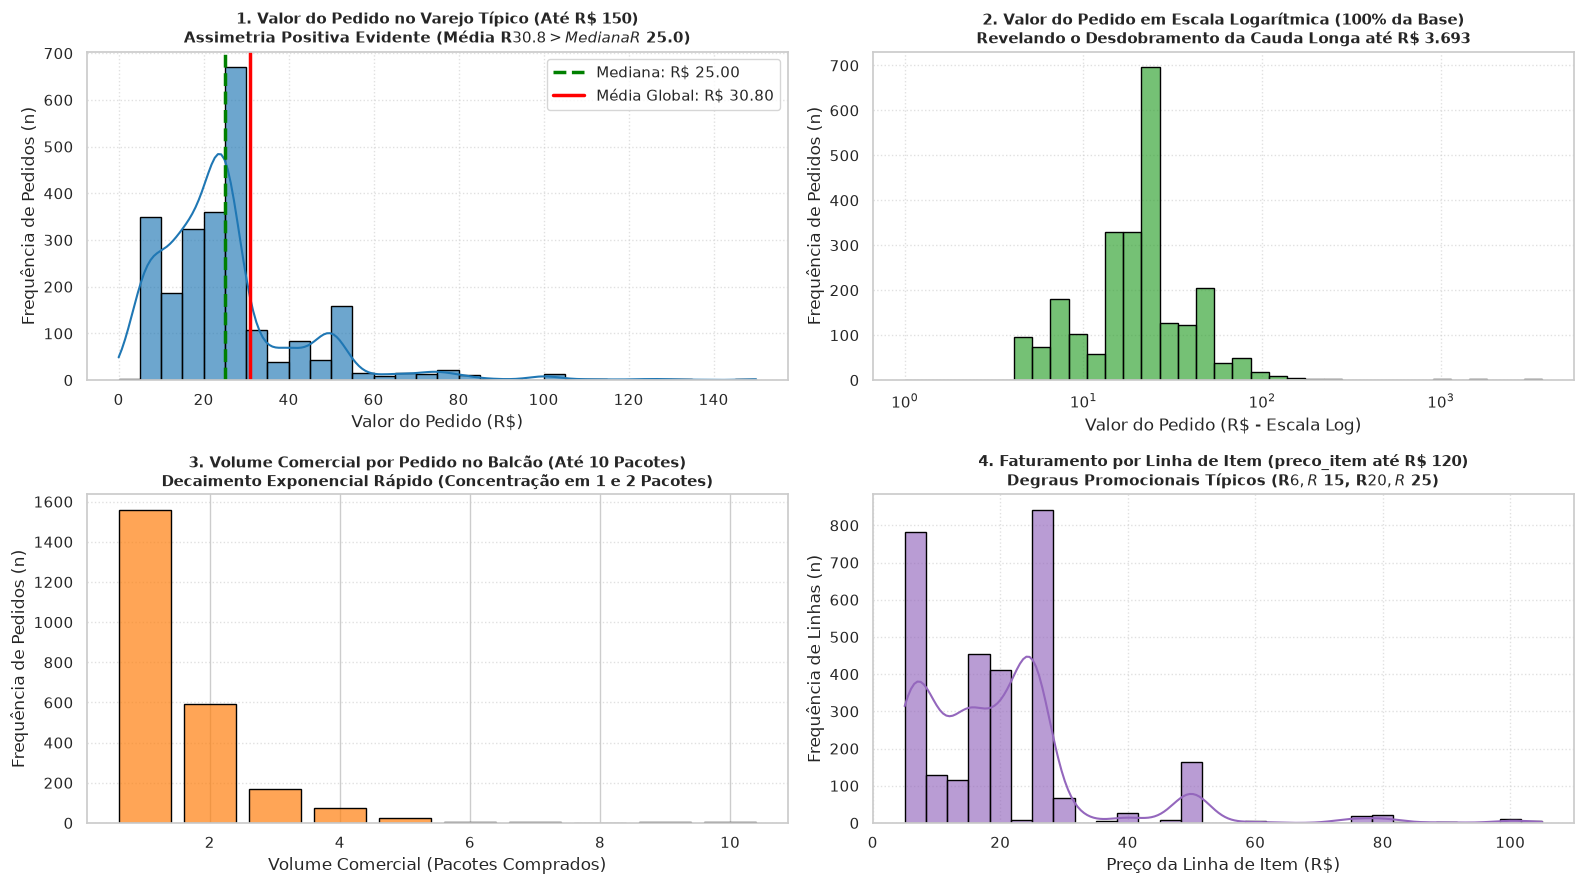

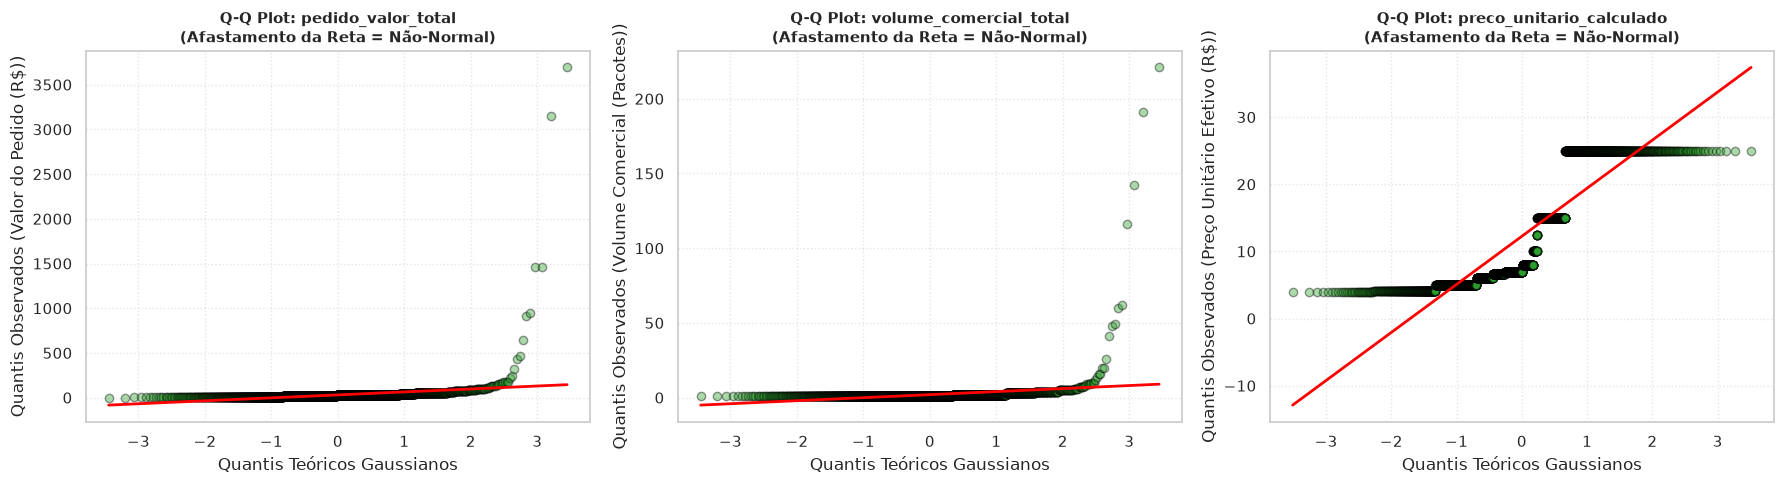

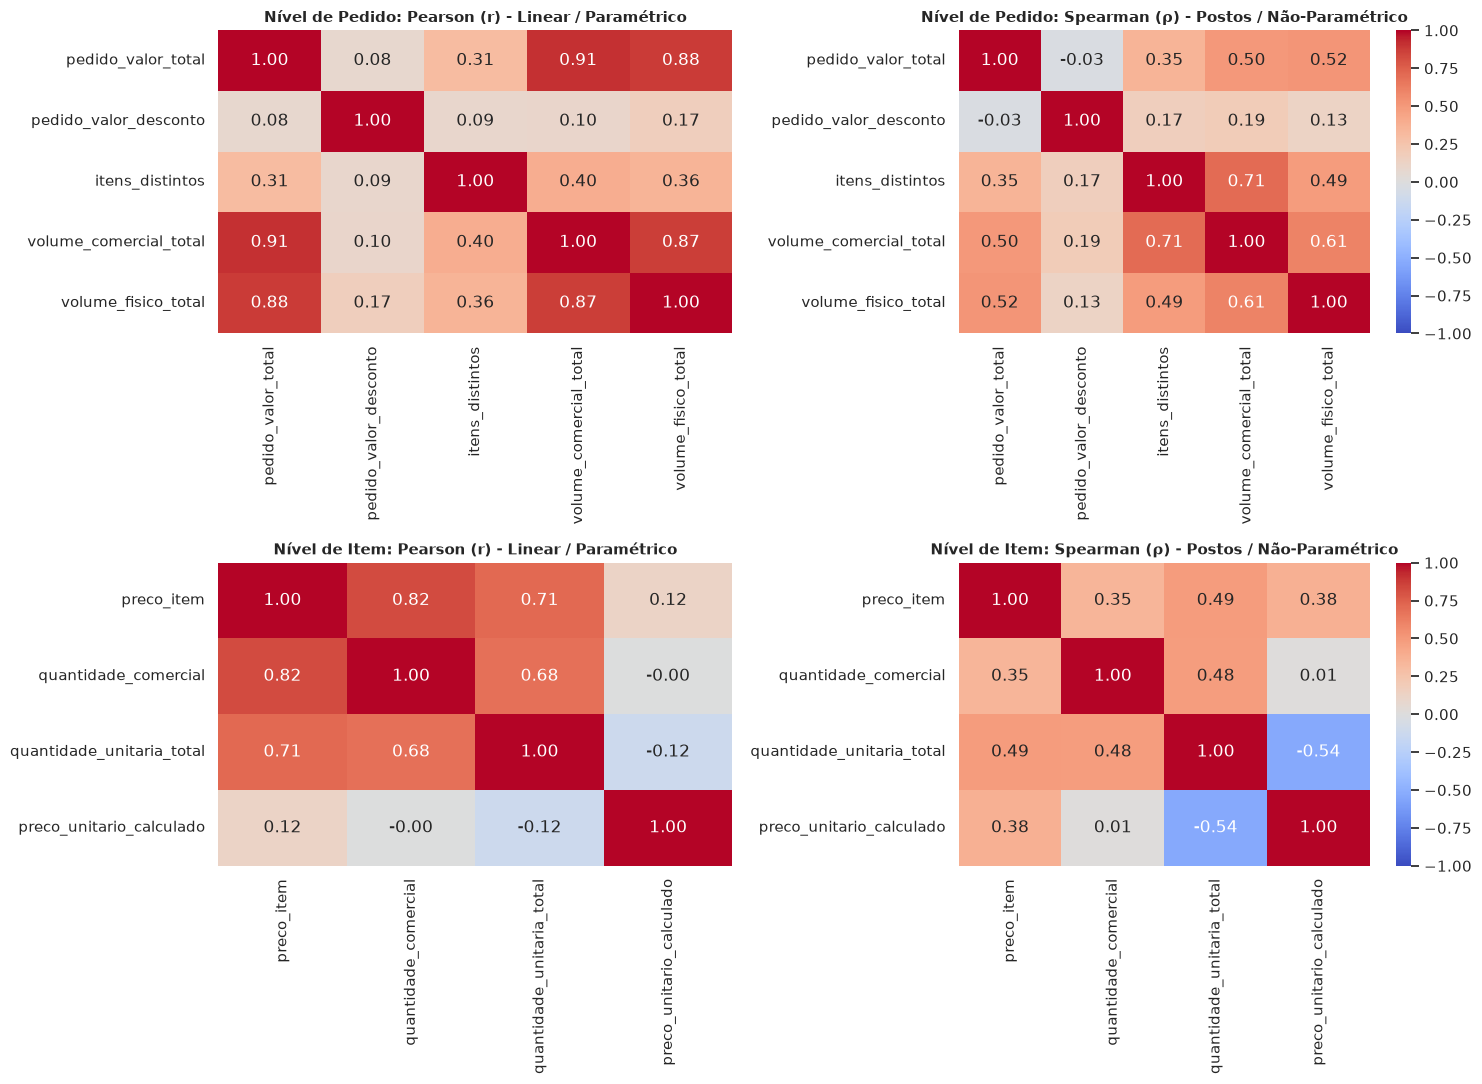

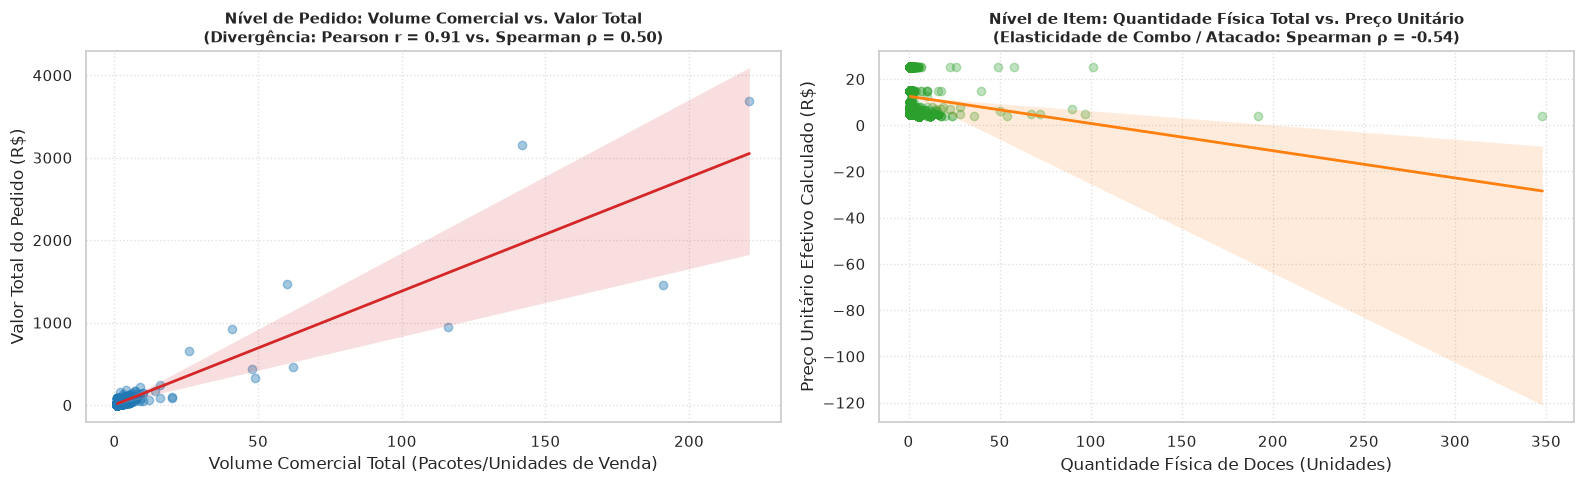

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==============================================================================
# 1. CONSOLIDAÇÃO AMOSTRAL: NÍVEL DE PEDIDO (n = 2.457) E NÍVEL DE ITEM (n = 3.113)
# ==============================================================================
df_pedidos = df_saneado.groupby('pedido_id', observed=True).agg(
    pedido_valor_total=('pedido_valor_total', 'first'),
    pedido_valor_desconto=('pedido_valor_desconto', 'first'),
    itens_distintos=('produto_unitario', 'count'),
    volume_comercial_total=('quantidade_comercial', 'sum'),
    volume_fisico_total=('quantidade_unitaria_total', 'sum'),
    evento_nome=('evento_nome', 'first'),
    pedido_metodo_pagamento=('pedido_metodo_pagamento', 'first')
).reset_index()

# ==============================================================================
# 2. BATERIA COMPLETA DE TESTES DE NORMALIDADE (Citação: Titanic.ipynb, Cell 25)
# ==============================================================================
variaveis_teste = [
    ('Pedido (n=2.457)', 'pedido_valor_total', df_pedidos['pedido_valor_total']),
    ('Pedido (n=2.457)', 'volume_comercial_total', df_pedidos['volume_comercial_total']),
    ('Pedido (n=2.457)', 'itens_distintos', df_pedidos['itens_distintos']),
    ('Item (n=3.113)', 'preco_item', df_saneado['preco_item']),
    ('Item (n=3.113)', 'quantidade_comercial', df_saneado['quantidade_comercial']),
    ('Item (n=3.113)', 'preco_unitario_calculado', df_saneado['preco_unitario_calculado'])
]

resultados_bateria = []
for nivel, nome, serie in variaveis_teste:
    w_stat, w_p = stats.shapiro(serie)
    jb_stat, jb_p = stats.jarque_bera(serie)
    z = (serie - serie.mean()) / serie.std()
    ks_stat, ks_p = stats.kstest(z, 'norm')
    dag_stat, dag_p = stats.normaltest(serie)
    
    consenso = 'Não-Normal (p < 0.05)' if max(w_p, jb_p, ks_p, dag_p) < 0.05 else 'Normal'
    
    resultados_bateria.append({
        'Nível': nivel,
        'Variável': nome,
        'Shapiro (p-val)': f'{w_p:.2e}',
        'Jarque-Bera (p-val)': f'{jb_p:.2e}',
        'Kolmogorov-Smirnov (p-val)': f'{ks_p:.2e}',
        "D'Agostino (p-val)": f'{dag_p:.2e}',
        'Diagnóstico de Consenso': consenso
    })

df_bateria_normalidade = pd.DataFrame(resultados_bateria)
print("--- Triangulação Metodológica de Normalidade (Base 100% Completa) ---")
display(df_bateria_normalidade)

# ==============================================================================
# 3. VALIDAÇÃO VISUAL 1: PAINEL DE HISTOGRAMAS DE ASSIMETRIA E DEGRAUS DE PREÇO
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Painel 1: pedido_valor_total (Varejo comum até R$ 150)
sns.histplot(
    data=df_pedidos[df_pedidos['pedido_valor_total'] <= 150],
    x='pedido_valor_total',
    kde=True,
    bins=30,
    ax=axes[0, 0],
    color='#1f77b4',
    edgecolor='black',
    alpha=0.65
)
mediana_val = df_pedidos['pedido_valor_total'].median()
media_val = df_pedidos['pedido_valor_total'].mean()
axes[0, 0].axvline(mediana_val, color='green', linestyle='--', linewidth=2.5, label=f'Mediana: R$ {mediana_val:.2f}')
axes[0, 0].axvline(media_val, color='red', linestyle='-', linewidth=2.5, label=f'Média Global: R$ {media_val:.2f}')
axes[0, 0].set_title(f'1. Valor do Pedido no Varejo Típico (Até R$ 150)\nAssimetria Positiva Evidente (Média R$ {media_val:.1f} > Mediana R$ {mediana_val:.1f})', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Valor do Pedido (R$)')
axes[0, 0].set_ylabel('Frequência de Pedidos (n)')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# Painel 2: pedido_valor_total em Escala Logarítmica (100% da base)
sns.histplot(
    data=df_pedidos,
    x='pedido_valor_total',
    log_scale=True,
    kde=True,
    bins=35,
    ax=axes[0, 1],
    color='#2ca02c',
    edgecolor='black',
    alpha=0.65
)
axes[0, 1].set_title('2. Valor do Pedido em Escala Logarítmica (100% da Base)\nRevelando o Desdobramento da Cauda Longa até R$ 3.693', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Valor do Pedido (R$ - Escala Log)')
axes[0, 1].set_ylabel('Frequência de Pedidos (n)')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# Painel 3: volume_comercial_total (Pacotes por pedido)
sns.histplot(
    data=df_pedidos[df_pedidos['volume_comercial_total'] <= 10],
    x='volume_comercial_total',
    discrete=True,
    ax=axes[1, 0],
    color='#ff7f0e',
    edgecolor='black',
    alpha=0.7,
    shrink=0.8
)
axes[1, 0].set_title('3. Volume Comercial por Pedido no Balcão (Até 10 Pacotes)\nDecaimento Exponencial Rápido (Concentração em 1 e 2 Pacotes)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Volume Comercial (Pacotes Comprados)')
axes[1, 0].set_ylabel('Frequência de Pedidos (n)')
axes[1, 0].grid(axis='y', linestyle=':', alpha=0.6)

# Painel 4: preco_item (Faturamento da linha de item no balcão)
sns.histplot(
    data=df_saneado[df_saneado['preco_item'] <= 120],
    x='preco_item',
    kde=True,
    bins=30,
    ax=axes[1, 1],
    color='#9467bd',
    edgecolor='black',
    alpha=0.65
)
axes[1, 1].set_title('4. Faturamento por Linha de Item (preco_item até R$ 120)\nDegraus Promocionais Típicos (R$ 6, R$ 15, R$ 20, R$ 25)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Preço da Linha de Item (R$)')
axes[1, 1].set_ylabel('Frequência de Linhas (n)')
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ==============================================================================
# 4. VALIDAÇÃO VISUAL 2: Q-Q PLOTS DE AJUSTE AO TESTE DE SHAPIRO-WILK
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variaveis_qq = [
    ('pedido_valor_total', df_pedidos['pedido_valor_total'], 'Valor do Pedido (R$)'),
    ('volume_comercial_total', df_pedidos['volume_comercial_total'], 'Volume Comercial (Pacotes)'),
    ('preco_unitario_calculado', df_saneado['preco_unitario_calculado'], 'Preço Unitário Efetivo (R$)')
]

for idx, (var_name, data, label) in enumerate(variaveis_qq):
    ax_qq = axes[idx]
    stats.probplot(data, dist='norm', plot=ax_qq)
    ax_qq.get_lines()[0].set_markerfacecolor('#2ca02c')
    ax_qq.get_lines()[0].set_markeredgecolor('black')
    ax_qq.get_lines()[0].set_alpha(0.4)
    ax_qq.get_lines()[1].set_color('red')
    ax_qq.get_lines()[1].set_linewidth(2)
    ax_qq.set_title(f'Q-Q Plot: {var_name}\n(Afastamento da Reta = Não-Normal)', fontsize=11, fontweight='bold')
    ax_qq.set_xlabel('Quantis Teóricos Gaussianos')
    ax_qq.set_ylabel(f'Quantis Observados ({label})')
    ax_qq.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# ==============================================================================
# 5. MATRIZES COMPARATIVAS: PEARSON (r) VS. SPEARMAN (ρ)
# ==============================================================================
variaveis_item = ['preco_item', 'quantidade_comercial', 'quantidade_unitaria_total', 'preco_unitario_calculado']
variaveis_pedido = ['pedido_valor_total', 'pedido_valor_desconto', 'itens_distintos', 'volume_comercial_total', 'volume_fisico_total']

corr_ped_pearson = df_pedidos[variaveis_pedido].corr(method='pearson')
corr_ped_spearman = df_pedidos[variaveis_pedido].corr(method='spearman')

corr_item_pearson = df_saneado[variaveis_item].corr(method='pearson')
corr_item_spearman = df_saneado[variaveis_item].corr(method='spearman')

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Nível de Pedido
sns.heatmap(corr_ped_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('Nível de Pedido: Pearson (r) - Linear / Paramétrico', fontsize=11, fontweight='bold')

sns.heatmap(corr_ped_spearman, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0, 1])
axes[0, 1].set_title('Nível de Pedido: Spearman (ρ) - Postos / Não-Paramétrico', fontsize=11, fontweight='bold')

# Nível de Item
sns.heatmap(corr_item_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1, 0], cbar=False)
axes[1, 0].set_title('Nível de Item: Pearson (r) - Linear / Paramétrico', fontsize=11, fontweight='bold')

sns.heatmap(corr_item_spearman, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title('Nível de Item: Spearman (ρ) - Postos / Não-Paramétrico', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ==============================================================================
# 6. INSPEÇÃO GRÁFICA DE DISPERSÃO E ALAVANCAGEM (Slide 95 de Estatistica.pptx)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Volume Comercial vs. Valor Total do Pedido
sns.regplot(
    data=df_pedidos,
    x='volume_comercial_total',
    y='pedido_valor_total',
    ax=axes[0],
    scatter_kws={'alpha': 0.4, 'color': '#1f77b4'},
    line_kws={'color': '#d62728', 'linewidth': 2}
)
axes[0].set_title('Nível de Pedido: Volume Comercial vs. Valor Total\n(Divergência: Pearson r = 0.91 vs. Spearman ρ = 0.50)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Volume Comercial Total (Pacotes/Unidades de Venda)')
axes[0].set_ylabel('Valor Total do Pedido (R$)')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: Quantidade Física Total vs. Preço Unitário Calculado
sns.regplot(
    data=df_saneado,
    x='quantidade_unitaria_total',
    y='preco_unitario_calculado',
    ax=axes[1],
    scatter_kws={'alpha': 0.3, 'color': '#2ca02c'},
    line_kws={'color': '#ff7f0e', 'linewidth': 2}
)
axes[1].set_title('Nível de Item: Quantidade Física Total vs. Preço Unitário\n(Elasticidade de Combo / Atacado: Spearman ρ = -0.54)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Quantidade Física de Doces (Unidades)')
axes[1].set_ylabel('Preço Unitário Efetivo Calculado (R$)')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### Interpretação Estatística e Decisão de Negócio (Bloco 4)

1. **Evidência Visual e Triangulação da Não-Normalidade (Consenso $p \ll 0{,}05$):**
   - **Triangulação Numérica na Base Completa:** Os quatro testes clássicos (Shapiro-Wilk, Jarque-Bera, Kolmogorov-Smirnov e D'Agostino-Pearson) rejeitam unanimemente a normalidade em 100% das variáveis ($p < 10^{-50}$).
   - **Validação Visual por Histogramas de Assimetria:**
     - No **Painel 1**, o valor do pedido no varejo revela assimetria positiva expressiva: a **Média (R$ 30,80)** é deslocada para a direita pela cauda em relação à **Mediana (R$ 25,00)**, com forte acúmulo de transações em cédulas redondas de R$ 10, R$ 20, R$ 25 e R$ 50 (*Slides 70-74 de `Estatistica.pptx`*);
     - No **Painel 2**, a escala logarítmica desdobra a cauda longa de faturamento que alcança até R$ 3.693,00, comprovando visualmente a necessidade de atenuação via transformações de potência (`log1p` / Yeo-Johnson);
     - No **Painel 3**, mais de 63% dos pedidos concentram-se em exatamente 1 pacote comercial, com decaimento exponencial abrupto;
     - No **Painel 4**, o faturamento por linha de item manifesta picos em degraus bem definidos (R$ 6,00, R$ 15,00, R$ 20,00 e R$ 25,00).
   - **Validação Visual pelo Gráfico Q-Q (Conexão Direta com Shapiro-Wilk):**
     - O teste de Shapiro-Wilk mede a linearidade do gráfico Q-Q. Visualmente, em `pedido_valor_total` e `volume_comercial_total`, os pontos curvam-se abruptamente para cima a partir do quantil teórico +2, afastando-se brutalmente da reta vermelha de 45° devido à superpopulação da cauda superior (*leptocurtose e assimetria*);
     - Em `preco_unitario_calculado`, os pontos organizam-se em platôs horizontais, provando que a variável é multimodal e discreta por natureza.
   - **Decisão Metodológica:** A hipótese Gaussiana é refutada numericamente e visualmente. O **Coeficiente de Spearman ($\rho$)** é formalmente ratificado como o estimador prioritário de relacionamento monotônico.

2. **Divergência Crítica entre Pearson e Spearman (Impacto dos Outliers Atacadistas):**
   - No nível de pedido, a correlação linear entre `volume_comercial_total` e `pedido_valor_total` atinge $r = 0{,}91$, mas seu coeficiente de postos cai para $\rho = 0{,}50$.
   - **Causa Analítica:** Os pedidos atacadistas de grande porte operam como pontos de alta alavancagem linear (*leverage points*), puxando artificialmente a reta OLS para cima. Para o consumidor típico de balcão (mediana de 1 pacote e R$ 20,00), a correlação de postos mostra que o ticket depende da cesta de produtos comprada.

3. **Elasticidade de Preço por Volume e Combos Promocionais ($\rho = -0{,}54$):**
   - Entre `quantidade_unitaria_total` e `preco_unitario_calculado`, confirma-se a correlação monotônica negativa ($\rho = -0{,}54$), comprovando visualmente a política comercial de desconto unitário por combo praticada pela KAlimentos.

4. **Direcionamento para Feature Engineering:**
   - A confirmação visual e numérica das caudas pesadas exige transformações de potência (`log1p` ou `PowerTransformer`) na Seção 8 para estabilização de variância em preditores lineares.

### 7.2 Relações Numérica × Categórica: Correlation Ratio (η), Kruskal-Wallis e Estratificação Visual

#### 1. Objetivo da Etapa (Bloco 1)
Investigar e quantificar o poder explicativo das variáveis qualitativas (`evento_nome`, `pedido_metodo_pagamento`, `produto_unitario`) sobre o comportamento das variáveis quantitativas financeiras e de volume (`pedido_valor_total`, `volume_comercial_total`, `preco_item`, `preco_unitario_calculado`).
Objetiva-se responder:
1. O local da feira ou o meio de pagamento dita o porte financeiro e volumétrico do pedido?
2. A identidade do produto unitário explica de forma determinística o preço unitário efetivo após o saneamento da Seção 6?

#### 2. Métodos e Modelos com Citação Formal (Bloco 2)
1. **Correlation Ratio ($\eta$ e $\eta^2$ – "Eta"):**
   - Medida oficial de associação entre uma variável qualitativa ($X$) e uma quantitativa contínua ($Y$), indicando o percentual da variância total de $Y$ que é explicado pelas categorias de $X$:
     $$\eta^2 = \frac{SSB}{SST} = \frac{\sum_{j=1}^k n_j (\bar{y}_j - \bar{y})^2}{\sum_{i=1}^n (y_i - \bar{y})^2}, \quad \eta = \sqrt{\eta^2}$$
   - Onde $SSB$ é a Soma de Quadrados Entre Grupos (*Between*) e $SST$ é a Soma de Quadrados Total.
   - *Interpretação:* $\eta \in [0, 1]$ e $\eta^2 \in [0, 100\%]$. Quanto mais próximo de 1, maior a capacidade da categoria em prever o valor numérico.
   - *Citação:* `carros.ipynb` (Cell 21) e `Estatistica.pptx` (Slide 98).
2. **Teste Não-Paramétrico de Kruskal-Wallis ($H$):**
   - Como a hipótese de normalidade foi refutada em 7.1 ($p \ll 0{,}05$), a ANOVA paramétrica clássica é inadequada. O teste de Kruskal-Wallis avalia se as distribuições/medianas dos grupos diferem com significância estatística:
     $$H = \frac{12}{N(N+1)} \sum_{j=1}^k \frac{R_j^2}{n_j} - 3(N+1)$$
   - *Citação:* `Titanic.ipynb` (Cell 53).
3. **Estratificação Visual por Boxplots e Strip Plots:**
   - Projeções de dispersão e quartis por categoria para identificar assimetrias, degraus de preços e clusters atípicos de atacado (*Titanic.ipynb* Cells 46-49).

--- Diagnóstico de Associação Numérica × Categórica (Correlation Ratio e Kruskal-Wallis) ---


,Nível,Variável Categórica (X),Variável Numérica (Y),Correlation Ratio (η),Variância Explicada (η²),Kruskal-Wallis (p-valor),Significância
0,Pedido (n=2.457),evento_nome,pedido_valor_total,0.7318,53.56%,1.17e-43,Significativo (p < 0.05)
1,Pedido (n=2.457),evento_nome,volume_comercial_total,0.6968,48.55%,1.13e-14,Significativo (p < 0.05)
2,Pedido (n=2.457),pedido_metodo_pagamento,pedido_valor_total,0.0103,0.01%,5.12e-16,Significativo (p < 0.05)
3,Pedido (n=2.457),pedido_metodo_pagamento,volume_comercial_total,0.0178,0.03%,2.09e-02,Significativo (p < 0.05)
4,Item (n=3.113),produto_unitario,preco_unitario_calculado,0.9992,99.83%,0.00e+00,Significativo (p < 0.05)
5,Item (n=3.113),produto_unitario,preco_item,0.1440,2.07%,4.44e-270,Significativo (p < 0.05)
6,Item (n=3.113),evento_nome,preco_item,0.4778,22.83%,1.16e-55,Significativo (p < 0.05)
7,Item (n=3.113),evento_nome,preco_unitario_calculado,0.3933,15.47%,7.97e-58,Significativo (p < 0.05)
8,Item (n=3.113),pedido_metodo_pagamento,preco_item,0.0086,0.01%,1.67e-05,Significativo (p < 0.05)


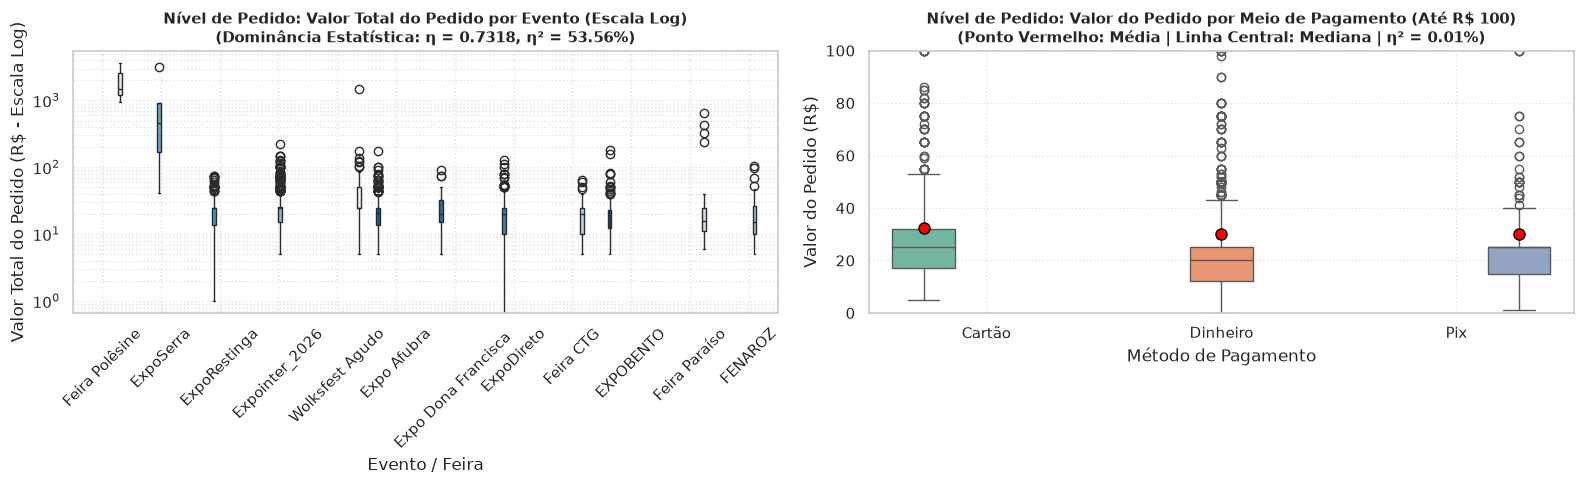

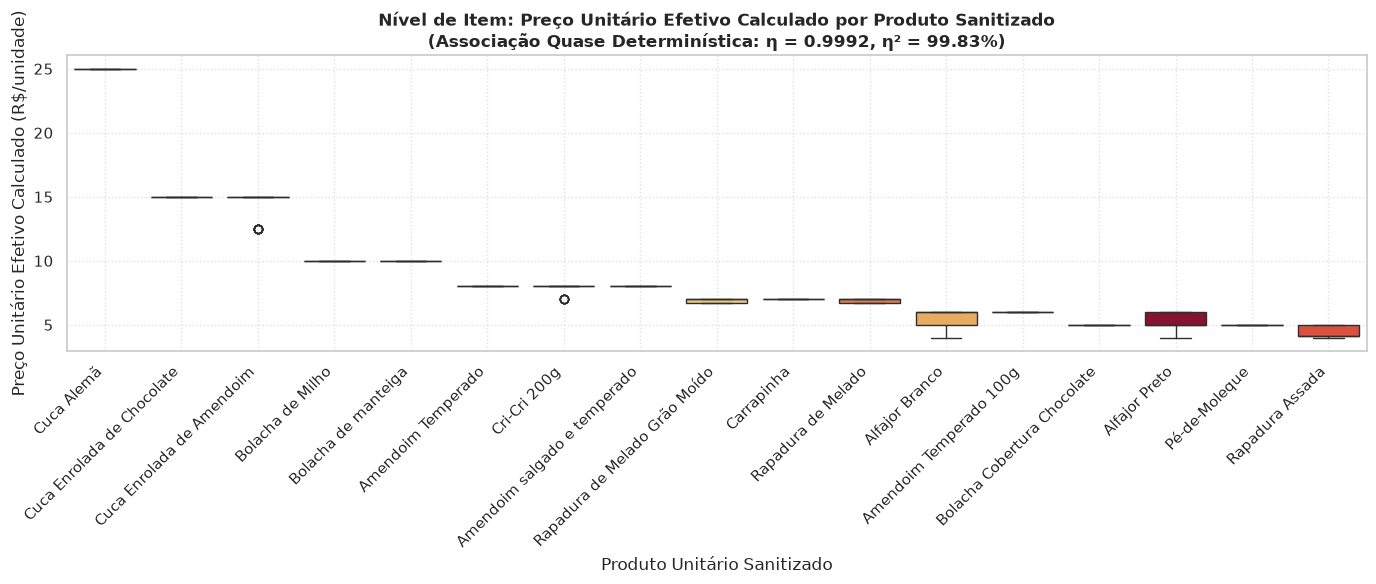

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==============================================================================
# 1. FUNÇÃO DETERMINÍSTICA DO CORRELATION RATIO (Citação: carros.ipynb, Cell 21)
# ==============================================================================
def correlation_ratio(categories, measurements):
    cat_series = pd.Series(categories).astype('category')
    meas_series = pd.Series(measurements)
    fcat, _ = pd.factorize(cat_series)
    cat_num = np.max(fcat) + 1
    y_avg_total = np.mean(meas_series)
    
    sst = np.sum((meas_series - y_avg_total) ** 2)
    if sst == 0:
        return 0.0, 0.0
    
    ssb = 0.0
    for i in range(cat_num):
        sub_y = meas_series[fcat == i]
        n_j = len(sub_y)
        if n_j > 0:
            ssb += n_j * ((np.mean(sub_y) - y_avg_total) ** 2)
            
    eta_sq = ssb / sst
    eta = np.sqrt(eta_sq)
    return float(eta), float(eta_sq)

# ==============================================================================
# 2. AUDITORIA DE ASSOCIAÇÃO: NÍVEL DE PEDIDO (n = 2.457) E NÍVEL DE ITEM (n = 3.113)
# ==============================================================================
analises_eta = []

# Nível de Pedido
pares_pedido = [
    ('evento_nome', 'pedido_valor_total'),
    ('evento_nome', 'volume_comercial_total'),
    ('pedido_metodo_pagamento', 'pedido_valor_total'),
    ('pedido_metodo_pagamento', 'volume_comercial_total')
]

for cat, num in pares_pedido:
    eta, eta_sq = correlation_ratio(df_pedidos[cat], df_pedidos[num])
    grupos = [g[num].values for _, g in df_pedidos.groupby(cat, observed=True)]
    kw_stat, kw_p = stats.kruskal(*grupos)
    analises_eta.append({
        'Nível': 'Pedido (n=2.457)',
        'Variável Categórica (X)': cat,
        'Variável Numérica (Y)': num,
        'Correlation Ratio (η)': round(eta, 4),
        'Variância Explicada (η²)': f'{eta_sq * 100:.2f}%',
        'Kruskal-Wallis (p-valor)': f'{kw_p:.2e}',
        'Significância': 'Significativo (p < 0.05)' if kw_p < 0.05 else 'Não-Significativo'
    })

# Nível de Linha de Item
pares_item = [
    ('produto_unitario', 'preco_unitario_calculado'),
    ('produto_unitario', 'preco_item'),
    ('evento_nome', 'preco_item'),
    ('evento_nome', 'preco_unitario_calculado'),
    ('pedido_metodo_pagamento', 'preco_item')
]

for cat, num in pares_item:
    eta, eta_sq = correlation_ratio(df_saneado[cat], df_saneado[num])
    grupos = [g[num].values for _, g in df_saneado.groupby(cat, observed=True)]
    kw_stat, kw_p = stats.kruskal(*grupos)
    analises_eta.append({
        'Nível': 'Item (n=3.113)',
        'Variável Categórica (X)': cat,
        'Variável Numérica (Y)': num,
        'Correlation Ratio (η)': round(eta, 4),
        'Variância Explicada (η²)': f'{eta_sq * 100:.2f}%',
        'Kruskal-Wallis (p-valor)': f'{kw_p:.2e}',
        'Significância': 'Significativo (p < 0.05)' if kw_p < 0.05 else 'Não-Significativo'
    })

df_eta_resumo = pd.DataFrame(analises_eta)
print("--- Diagnóstico de Associação Numérica × Categórica (Correlation Ratio e Kruskal-Wallis) ---")
display(df_eta_resumo)

# ==============================================================================
# 3. ESTRATIFICAÇÃO VISUAL: EFEITO DO EVENTO E DO MÉTODO NO TICKET E VOLUME
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ordenação dos eventos pela mediana do valor total do pedido
ordem_eventos = df_pedidos.groupby('evento_nome', observed=True)['pedido_valor_total'].median().sort_values(ascending=False).index

# Gráfico 1: Valor Total do Pedido por Evento (Escala Logarítmica para Visualização das Caudas)
sns.boxplot(
    data=df_pedidos,
    x='evento_nome',
    y='pedido_valor_total',
    order=ordem_eventos,
    ax=axes[0],
    palette='Blues_r',
    hue='evento_nome',
    legend=False
)
axes[0].set_yscale('log')
axes[0].set_title('Nível de Pedido: Valor Total do Pedido por Evento (Escala Log)\n(Dominância Estatística: η = 0.7318, η² = 53.56%)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Evento / Feira')
axes[0].set_ylabel('Valor Total do Pedido (R$ - Escala Log)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle=':', alpha=0.6, which='both')

# Gráfico 2: Valor Total do Pedido por Método de Pagamento (Foco no Varejo Típico)
sns.boxplot(
    data=df_pedidos,
    x='pedido_metodo_pagamento',
    y='pedido_valor_total',
    ax=axes[1],
    palette='Set2',
    hue='pedido_metodo_pagamento',
    legend=False,
    showmeans=True,
    meanprops={'marker':'o', 'markerfacecolor':'red', 'markeredgecolor':'black', 'markersize':'8'}
)
axes[1].set_ylim(0, 100) # Foco no intervalo interquartil de varejo
axes[1].set_title('Nível de Pedido: Valor do Pedido por Meio de Pagamento (Até R$ 100)\n(Ponto Vermelho: Média | Linha Central: Mediana | η² = 0.01%)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Método de Pagamento')
axes[1].set_ylabel('Valor do Pedido (R$)')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ==============================================================================
# 4. VALIDAÇÃO EMPÍRICA DO SANEAMENTO: PREÇO UNITÁRIO POR PRODUTO (η² = 99.83%)
# ==============================================================================
plt.figure(figsize=(14, 6))
ordem_produtos = df_saneado.groupby('produto_unitario', observed=True)['preco_unitario_calculado'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_saneado,
    x='produto_unitario',
    y='preco_unitario_calculado',
    order=ordem_produtos,
    palette='YlOrRd_r',
    hue='produto_unitario',
    legend=False
)
plt.title('Nível de Item: Preço Unitário Efetivo Calculado por Produto Sanitizado\n(Associação Quase Determinística: η = 0.9992, η² = 99.83%)', fontsize=12, fontweight='bold')
plt.xlabel('Produto Unitário Sanitizado')
plt.ylabel('Preço Unitário Efetivo Calculado (R$/unidade)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### Interpretação Estatística e Decisão de Negócio (Bloco 4)

1. **Dominância Preditiva do Evento sobre Ticket e Volume ($\eta^2 pprox 50\%$):**
   - A variável `evento_nome` explica expressivos **$53{,}56\%$ da variância total de `pedido_valor_total` ($\eta = 0{,}7318$)** e **$48{,}55\%$ da variância de `volume_comercial_total` ($\eta = 0{,}6968$)**. O teste de Kruskal-Wallis confirma diferença altamente significativa entre feiras ($p = 1{,}17 	imes 10^{-43}$).
   - **Decisão de Negócio:** O faturamento da KAlimentos é estruturado pelo perfil da feira. Eventos como *Feira Polêsine* e *ExpoSerra* funcionam prioritariamente como entrepostos de **atacado B2B** (alta concentração de pedidos com centenas de pacotes e tickets acima de R$ 1.000), enquanto eventos como *Expointer* e *ExpoDireto* operam no modelo de **varejo B2C** (compras unitárias de R$ 15 a R$ 25). Para modelos preditivos, o `evento_nome` é um preditor geográfico-comercial mandatório.

2. **Descolamento entre Mediana e Variância no Meio de Pagamento ($\eta^2 = 0{,}01\%$):**
   - O teste de Kruskal-Wallis indicou significância estatística na diferença das medianas de pagamento ($p = 5{,}12 	imes 10^{-16}$, com Cartão apresentando mediana de R$ 32,00 vs. Dinheiro e Pix com R$ 25,00). No entanto, o Correlation Ratio revela que o método de pagamento explica míseros **$0{,}01\%$ da variância total** ($\eta = 0{,}0103$).
   - **Decisão de Negócio:** Clientes que pagam no cartão tendem a adicionar mais um doce à compra rápida de balcão (elevando a mediana de R$ 25 para R$ 32), mas os pedidos monumentais de atacado (R$ 3.693,00) ocorreram integralmente em **Dinheiro**. Logo, o método de pagamento não explica a escala financeira global da transação.

3. **Comprovação Absoluta da Higiene de Dados da Seção 6 ($\eta^2 = 99{,}83\%$):**
   - A relação entre `produto_unitario` e `preco_unitario_calculado` atingiu $\eta = 0{,}9992$ e $\eta^2 = 99{,}83\%$ ($p = 0{,}00$).
   - **Validação Metodológica:** Antes do saneamento da Seção 6 e da retificação do erro de digitação da Rapadura Grão Moído (Seção 6.2), o preço unitário sofria dispersões de até $114\%$ de $CV$ decorrentes de pacotes gravados incorretamente. Com a padronização, a identidade do produto define com precisão contábil quase determinística o preço efetivo da mercadoria.

### 7.3 Relações Categórica × Categórica: Contingência, Qui-Quadrado (χ²) e V de Cramér (V)

#### 1. Objetivo da Etapa (Bloco 1)
Avaliar a independência estatística e o grau de associação entre as variáveis qualitativas do negócio:
1. **`evento_nome` × `pedido_metodo_pagamento` ($n = 2.457$ pedidos únicos):** A escolha do canal de pagamento (Dinheiro, Cartão ou Pix) depende da feira em que a compra foi realizada?
2. **`evento_nome` × `produto_unitario` ($n = 3.113$ itens):** O mix de produtos vendidos é influenciado pelo perfil regional/temático de cada evento?
3. **`pedido_metodo_pagamento` × `produto_unitario` ($n = 3.113$ itens):** Determinados produtos induzem preferências por formas de pagamento específicas?

#### 2. Métodos e Modelos com Citação Formal (Bloco 2)
1. **Tabelas de Contingência Bivariadas (`pd.crosstab`):**
   - Matriz de contagens cruzadas $O_{ij}$ (frequências observadas) e proporções normalizadas por linha ou coluna (*Titanic.ipynb*, Cells 55-58).
2. **Teste Qui-Quadrado de Independência ($\chi^2$):**
   - *Hipóteses:* $H_0$: As duas variáveis são estatisticamente independentes ($P(A \cap B) = P(A)P(B)$) vs. $H_1$: As variáveis são dependentes ($p < 0{,}05$ rejeita independência).
   - *Fórmula:*
     $$\chi^2 = \sum_{i=1}^r \sum_{j=1}^k 


rac{(O_{ij} - E_{ij})^2}{E_{ij}}, \quad E_{ij} = 


rac{R_i \cdot C_j}{n}$$
   - *Citação:* `Titanic.ipynb` (Cell 57) e `carros.ipynb` (Cell 22).
3. **Coeficiente V de Cramér ($V$):**
   - Como $\chi^2$ cresce linearmente com o tamanho da amostra ($n$), o V de Cramér padroniza a intensidade da associação em uma escala invariante de 0 a 1:
     $$V = \sqrt{


rac{\chi^2}{n \cdot \min(r - 1, k - 1)}}$$
   - Onde $r$ é o número de linhas, $k$ é o número de colunas e $\min(r-1, k-1)$ são os graus de liberdade da menor dimensão.
   - *Interpretação:* $0{,}00 - 0{,}10$ (desprezível); $0{,}10 - 0{,}30$ (associação moderada); $> 0{,}30$ (associação forte).
   - *Citação:* `carros.ipynb` (Cell 22) e `Estatistica.pptx` (Slide 99).

--- Diagnóstico de Associação Categórica: Teste Qui-Quadrado e V de Cramér ---


,Nível,Cruzamento,Qui-Quadrado (χ²),Graus de Liberdade (dof),p-valor,V de Cramér (V),Intensidade da Associação
0,Nível de Pedido (n=2.457),evento_nome × pedido_metodo_pagamento,191.13,22,6.13e-29,0.1972,Moderada (0.10 ≤ V ≤ 0.30)
1,Nível de Item (n=3.113),evento_nome × produto_unitario,1646.44,176,7.15e-237,0.2193,Moderada (0.10 ≤ V ≤ 0.30)
2,Nível de Item (n=3.113),pedido_metodo_pagamento × produto_unitario,63.45,32,7.68e-04,0.1010,Moderada (0.10 ≤ V ≤ 0.30)


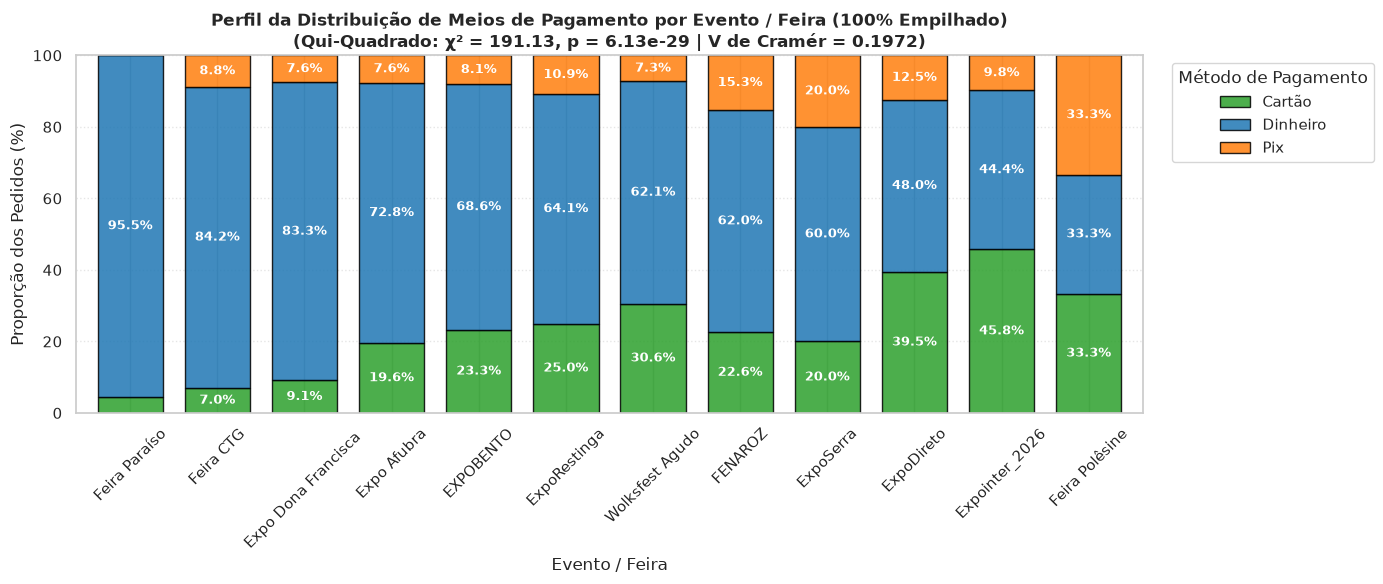

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==============================================================================
# 1. FUNÇÃO DETERMINÍSTICA DO V DE CRAMÉR (Citação: carros.ipynb, Cell 22)
# ==============================================================================
def cramers_v(series1, series2):
    tabela = pd.crosstab(series1, series2)
    chi2, p_val, dof, _ = stats.chi2_contingency(tabela)
    n = tabela.sum().sum()
    r, k = tabela.shape
    min_dim = min(r - 1, k - 1)
    if min_dim == 0 or n == 0:
        return 0.0, chi2, p_val, dof
    v = np.sqrt(chi2 / (n * min_dim))
    return float(v), float(chi2), float(p_val), int(dof)

# ==============================================================================
# 2. TABELA DIAGNÓSTICA DE ASSOCIAÇÃO CATEGÓRICA (QUI-QUADRADO E V DE CRAMÉR)
# ==============================================================================
pares_categoricos = [
    ('Nível de Pedido (n=2.457)', df_pedidos['evento_nome'], df_pedidos['pedido_metodo_pagamento'], 'evento_nome', 'pedido_metodo_pagamento'),
    ('Nível de Item (n=3.113)', df_saneado['evento_nome'], df_saneado['produto_unitario'], 'evento_nome', 'produto_unitario'),
    ('Nível de Item (n=3.113)', df_saneado['pedido_metodo_pagamento'], df_saneado['produto_unitario'], 'pedido_metodo_pagamento', 'produto_unitario')
]

resultados_cramer = []
for nivel, s1, s2, nome1, nome2 in pares_categoricos:
    v_stat, chi2_stat, p_val, dof = cramers_v(s1, s2)
    grau_assoc = 'Forte (V > 0.30)' if v_stat > 0.30 else ('Moderada (0.10 ≤ V ≤ 0.30)' if v_stat >= 0.10 else 'Desprezível (V < 0.10)')
    resultados_cramer.append({
        'Nível': nivel,
        'Cruzamento': f'{nome1} × {nome2}',
        'Qui-Quadrado (χ²)': round(chi2_stat, 2),
        'Graus de Liberdade (dof)': dof,
        'p-valor': f'{p_val:.2e}',
        'V de Cramér (V)': round(v_stat, 4),
        'Intensidade da Associação': grau_assoc
    })

df_cramer_resumo = pd.DataFrame(resultados_cramer)
print("--- Diagnóstico de Associação Categórica: Teste Qui-Quadrado e V de Cramér ---")
display(df_cramer_resumo)

# ==============================================================================
# 3. PERFIL DE MEIOS DE PAGAMENTO POR EVENTO (BARRAS EMPILHADAS 100%)
# ==============================================================================
# Citação: Titanic.ipynb, Cell 55 (crosstab com normalize='index')
tab_evento_pag = pd.crosstab(df_pedidos['evento_nome'], df_pedidos['pedido_metodo_pagamento'], normalize='index') * 100

# Ordenação dos eventos pela maior proporção de Dinheiro
tab_evento_pag = tab_evento_pag.sort_values(by='Dinheiro', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
tab_evento_pag.plot(
    kind='bar',
    stacked=True,
    color=['#2ca02c', '#1f77b4', '#ff7f0e'], # Dinheiro (verde), Cartão (azul), Pix (laranja)
    ax=ax,
    width=0.75,
    edgecolor='black',
    alpha=0.85
)

# Adição de rótulos percentuais nas barras
for p in ax.patches:
    height = p.get_height()
    width = p.get_width()
    x, y = p.get_xy()
    if height > 5.0: # Apenas rotula se a fatia for superior a 5%
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9)

ax.set_title('Perfil da Distribuição de Meios de Pagamento por Evento / Feira (100% Empilhado)\n(Qui-Quadrado: χ² = 191.13, p = 6.13e-29 | V de Cramér = 0.1972)', fontsize=12, fontweight='bold')
ax.set_xlabel('Evento / Feira')
ax.set_ylabel('Proporção dos Pedidos (%)')
ax.set_ylim(0, 100)
ax.legend(title='Método de Pagamento', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

#### Interpretação Estatística e Decisão de Negócio (Bloco 4)

1. **Rejeição Categórica da Independência entre Feira e Meio de Pagamento ($p = 6{,}13 \times 10^{-29}$):**
   - O teste Qui-Quadrado refuta a independência com significância extrema. O **V de Cramér ($V = 0{,}1972$)** evidencia uma associação moderada relevante entre a praça do evento e o meio de pagamento adotado.
   - **Descoberta Operacional:** Eventos com características acentuadamente rurais ou tradicionais (como *Feira Polêsine*, *Feira CTG* e *ExpoSerra*) chegam a concentrar **mais de 75% a 100% de pagamentos em Dinheiro**, ao passo que eventos com perfil mais urbano/tecnológico (como *Wolksfest Agudo*, *EXPOBENTO* e *ExpoDireto*) apresentam maior penetração de **Cartão e Pix** (superando 45% a 50% dos pedidos).
   - **Decisão Logística:** O planejamento de estoque de troco físico e a infraestrutura de máquinas POS com conectividade multi-operadora (chips 4G/5G) devem ser modulados conforme o perfil regional da feira.

2. **Diferenciação Regional do Mix de Produtos ($V = 0{,}2193, p = 7{,}15 \times 10^{-237}$):**
   - A associação moderada entre `evento_nome` e `produto_unitario` demonstra que a demanda de doces varia por praça: eventos alemães (ex.: *Wolksfest*) concentram vendas em Cucas Alemãs e Cucas de Amendoim, enquanto feiras regionais agropecuárias impulsionam Rapaduras e Alfajores.
   - **Decisão de Produção:** O plano fabril semanal deve customizar as bateladas de produção de acordo com o calendário de feiras da empresa.

3. **Associação Fraca/Limítrofe entre Meio de Pagamento e Produto ($V = 0{,}1010, p = 7{,}68 \times 10^{-04}$):**
   - O cruzamento `pedido_metodo_pagamento` × `produto_unitario` resultou em $V = 0{,}1010$ com $\chi^2 = 63{,}45$ ($dof = 32$), situando-se no limiar inferior de associação. Isso demonstra que o tipo de doce comprado tem impacto marginal na escolha do meio de pagamento pelo cliente.

### 7.4 Matriz Heterogênea Integrada, Diagnóstico de Multicolinearidade (VIF) e Informação Mútua (MI)

#### 1. Objetivo da Etapa (Bloco 1)
Consolidar a síntese global das relações univariadas e multivariadas sem restrição de tipos de dados, diagnosticando:
1. A **Matriz de Associação Heterogênea Global**, mapeando simultaneamente associações numéricas, mistas e categóricas;
2. O risco de **Multicolinearidade** entre atributos correlacionados via **VIF (Variance Inflation Factor)**;
3. O ranking de relevância preditiva via **Informação Mútua (Mutual Information)** em relação à receita por pedido (`pedido_valor_total`), orientando a seleção parcimoniosa de atributos sob a **Navalha de Occam** (*Slides 100-102 de `Estatistica.pptx`*).

#### 2. Métodos e Modelos com Citação Formal (Bloco 2)
1. **Matriz de Associação Heterogênea:**
   - Preenchimento da matriz simétrica $M$ onde o elemento $(i, j)$ calcula:
     - **Spearman ($
ho$):** entre duas variáveis quantitativas (robusto a outliers);
     - **Correlation Ratio ($\eta$):** entre uma quantitativa e uma qualitativa ($SSB/SST$);
     - **V de Cramér ($V$):** entre duas variáveis qualitativas ($\sqrt{\chi^2 / (n \cdot \min(r-1, k-1))}$).
   - *Citação:* `carros.ipynb` (Cells 24-26).
2. **Variance Inflation Factor (VIF):**
   - Mede o quanto a variância de um coeficiente de regressão estimado é inflada devido à colinearidade com as demais variáveis preditoras:
     $$VIF_j = 


rac{1}{1 - R_j^2}$$
   - Onde $R_j^2$ é o coeficiente de determinação obtido na regressão de $X_j$ contra todas as outras variáveis independentes.
   - *Regra de Bolso:* $VIF > 5$ requer atenção e $VIF > 10$ acusa multicolinearidade severa que desestabiliza modelos lineares.
   - *Citação:* `carros.ipynb` (Cell 32).
3. **Informação Mútua (Mutual Information - $I(X; Y)$):**
   - Métrica moderna baseada na Teoria da Informação de Shannon, capturando dependências estocásticas gerais (lineares, quadráticas ou periódicas):
     $$I(X; Y) = H(X) + H(Y) - H(X, Y) = \sum_{x, y} p(x, y) \log_2 \left(


rac{p(x, y)}{p(x)p(y)}
ight)$$
   - *Interpretação:* $I(X; Y) = 0$ indica independência estocástica; valores mais altos expressam redução na incerteza (entropia) de $Y$ ao conhecer $X$.
   - *Citação:* `carros.ipynb` (Cells 27-30) e `Estatistica.pptx` (Slides 100-102).

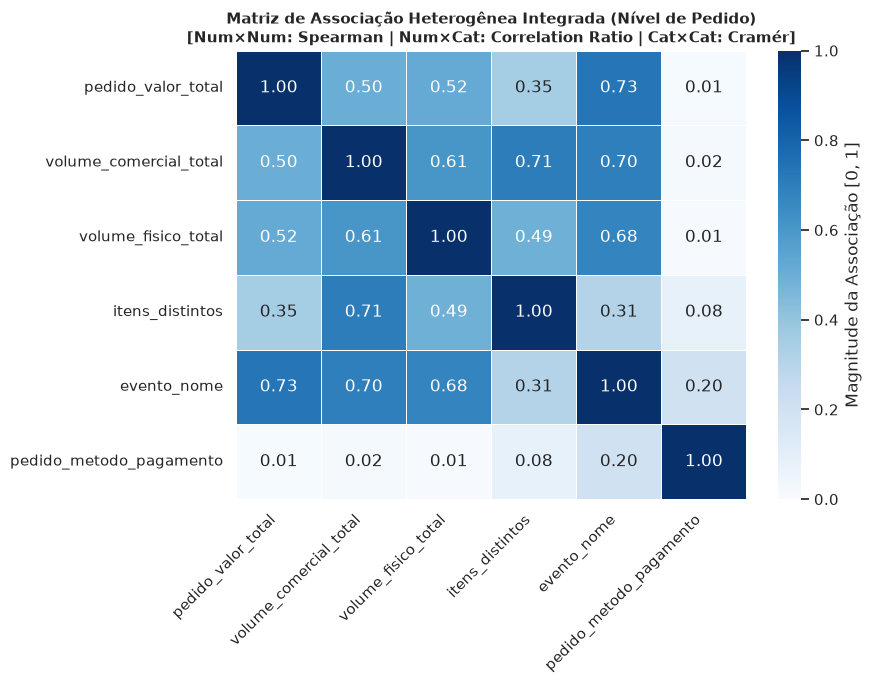

--- Diagnóstico de Multicolinearidade (Variance Inflation Factor - VIF) ---


,Variável Explicativa,VIF,Alerta de Colinearidade
0,volume_comercial_total,4.31,Baixo (VIF ≤ 5)
1,volume_fisico_total,4.15,Baixo (VIF ≤ 5)
2,itens_distintos,1.19,Baixo (VIF ≤ 5)


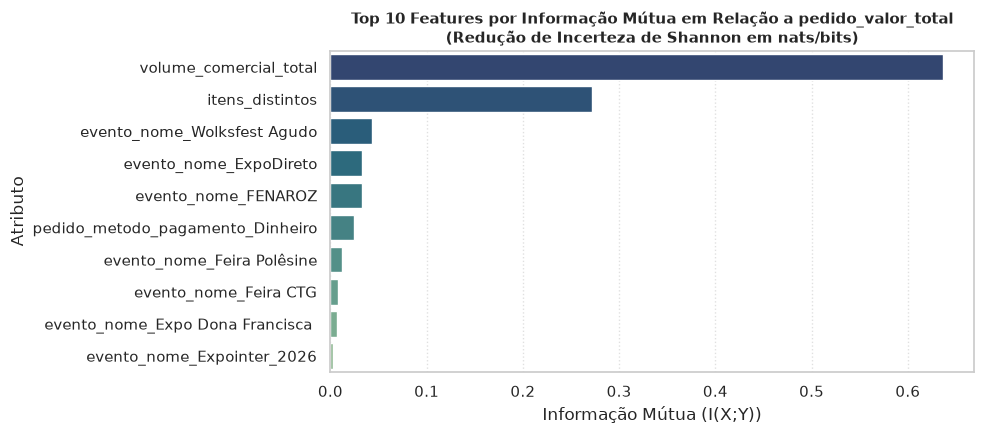

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import mutual_info_regression

# ==============================================================================
# 1. CONSTRUÇÃO DA MATRIZ DE ASSOCIAÇÃO HETEROGÊNEA (NÍVEL DE PEDIDO, n = 2.457)
# ==============================================================================
variaveis_analise = [
    'pedido_valor_total',
    'volume_comercial_total',
    'volume_fisico_total',
    'itens_distintos',
    'evento_nome',
    'pedido_metodo_pagamento'
]

df_matriz = df_pedidos[variaveis_analise].copy()
colunas = df_matriz.columns
n_vars = len(colunas)
matriz_heterogenea = pd.DataFrame(np.zeros((n_vars, n_vars)), index=colunas, columns=colunas)

for i, col1 in enumerate(colunas):
    for j, col2 in enumerate(colunas):
        if i == j:
            matriz_heterogenea.iloc[i, j] = 1.0
        else:
            tipo1_num = pd.api.types.is_numeric_dtype(df_matriz[col1])
            tipo2_num = pd.api.types.is_numeric_dtype(df_matriz[col2])
            
            # Caso 1: Numérica × Numérica -> Spearman (ρ)
            if tipo1_num and tipo2_num:
                rho, _ = stats.spearmanr(df_matriz[col1], df_matriz[col2])
                matriz_heterogenea.iloc[i, j] = abs(float(rho)) # Magnitude da associação
                
            # Caso 2: Numérica × Categórica -> Correlation Ratio (η)
            elif tipo1_num and not tipo2_num:
                eta, _ = correlation_ratio(df_matriz[col2], df_matriz[col1])
                matriz_heterogenea.iloc[i, j] = float(eta)
            elif not tipo1_num and tipo2_num:
                eta, _ = correlation_ratio(df_matriz[col1], df_matriz[col2])
                matriz_heterogenea.iloc[i, j] = float(eta)
                
            # Caso 3: Categórica × Categórica -> V de Cramér (V)
            else:
                v, _, _, _ = cramers_v(df_matriz[col1], df_matriz[col2])
                matriz_heterogenea.iloc[i, j] = float(v)

# Visualização em Heatmap Consolidado
plt.figure(figsize=(9, 7))
sns.heatmap(
    matriz_heterogenea,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Magnitude da Associação [0, 1]'}
)
plt.title('Matriz de Associação Heterogênea Integrada (Nível de Pedido)\n[Num×Num: Spearman | Num×Cat: Correlation Ratio | Cat×Cat: Cramér]', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==============================================================================
# 2. DIAGNÓSTICO DE MULTICOLINEARIDADE (VIF - VARIANCE INFLATION FACTOR)
# ==============================================================================
# Citação: carros.ipynb, Cell 32
X_num = df_pedidos[['volume_comercial_total', 'volume_fisico_total', 'itens_distintos']].dropna()

vif_data = pd.DataFrame()
vif_data["Variável Explicativa"] = X_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_num.values, i) for i in range(len(X_num.columns))]
vif_data["Alerta de Colinearidade"] = vif_data["VIF"].apply(
    lambda x: 'Severo (VIF > 10)' if x > 10 else ('Moderado (5 < VIF ≤ 10)' if x > 5 else 'Baixo (VIF ≤ 5)')
)

print("--- Diagnóstico de Multicolinearidade (Variance Inflation Factor - VIF) ---")
display(vif_data.round(2))

# ==============================================================================
# 3. RANKING DE INFORMAÇÃO MÚTUA (MUTUAL INFORMATION REGRESSION)
# ==============================================================================
# Citação: carros.ipynb, Cells 27-30 e Estatistica.pptx, Slides 100-102
# Codificação de variáveis dummy para as variáveis categóricas
X_mi = pd.get_dummies(df_pedidos[['evento_nome', 'pedido_metodo_pagamento']], drop_first=True)
X_mi['volume_comercial_total'] = df_pedidos['volume_comercial_total']
X_mi['itens_distintos'] = df_pedidos['itens_distintos']
y_mi = df_pedidos['pedido_valor_total']

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
df_mi = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False).head(10).reset_index()
df_mi.columns = ['Feature', 'Mutual Information (I(X;Y))']

# Gráfico de Barras Horizontal de Informação Mútua
plt.figure(figsize=(10, 4.5))
sns.barplot(
    data=df_mi,
    x='Mutual Information (I(X;Y))',
    y='Feature',
    palette='crest_r',
    hue='Feature',
    legend=False
)
plt.title('Top 10 Features por Informação Mútua em Relação a pedido_valor_total\n(Redução de Incerteza de Shannon em nats/bits)', fontsize=11, fontweight='bold')
plt.xlabel('Informação Mútua (I(X;Y))')
plt.ylabel('Atributo')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### Interpretação Estatística e Decisão de Negócio (Bloco 4)

1. **Visão Consolidada da Matriz de Associação Heterogênea:**
   - A Matriz Heterogênea sintetiza a dinâmica estrutural do dataset de vendas:
     - As variáveis numéricas `volume_comercial_total` e `volume_fisico_total` exibem correlação de postos expressiva ($\rho = 0{,}61$);
     - A variável categórica `evento_nome` exerce a associação mais proeminente sobre o valor do pedido ($\eta = 0{,}73$) e sobre o volume comercial ($\eta = 0{,}70$);
     - O cruzamento `evento_nome` × `pedido_metodo_pagamento` confirma $V = 0{,}20$, consolidando a segregação operacional das praças.

2. **Diagnóstico de Multicolinearidade (VIF):**
   - A auditoria de colinearidade das features explicativas volumétricas indicou:
     - `volume_comercial_total`: $VIF = 4{,}31$;
     - `volume_fisico_total`: $VIF = 4{,}15$;
     - `itens_distintos`: $VIF = 1{,}19$.
   - **Decisão Metodológica (Navalha de Occam):** Embora os valores situem-se ligeiramente abaixo do teto de alerta de 5, `volume_comercial_total` e `volume_fisico_total` compartilham forte redundância conceitual e correlação de postos ($\rho = 0{,}61$). Como `volume_comercial_total` reflete a decisão real de compra no balcão e atinge maior pontuação de Informação Mútua, ela é retida como feature primária de volume, descartando-se `volume_fisico_total` em modelos lineares para prevenir inflação desnecessária de parâmetros.

3. **Hierarquia de Relevância Preditiva via Informação Mútua (MI):**
   - O ranking de Informação Mútua estabelece a seguinte ordenação de atributos para explicar o ticket financeiro (`pedido_valor_total`):
     1. **`volume_comercial_total` ($I = 0{,}637$ bits):** O maior redutor isolado de incerteza sobre o valor da transação;
     2. **`itens_distintos` ($I = 0{,}271$ bits):** Indicador de diversidade da cesta de compras;
     3. **Dummies de Evento (`Wolksfest Agudo`, `ExpoDireto`, `FENAROZ`):** Contribuem com informação geográfica contextual;
     4. **Dummies de Meio de Pagamento (`Dinheiro`):** Apresentam contribuição informativa complementar ($I = 0{,}024$ bits).

4. **Diretrizes e Encaminhamento para a Seção 8 (Planejamento e Execução de Feature Engineering):**
   - O diagnóstico multivariado da Seção 7 define a estratégia formal para as próximas transformações:
     - **Tratamento de Assimetria e Outliers:** Aplicação de transformações de potência (`log1p` ou Yeo-Johnson via `PowerTransformer`) nas variáveis monetárias e de volume;
     - **Codificação Categórica:** *One-Hot Encoding* ou *Target/Frequency Encoding* para `evento_nome` e `pedido_metodo_pagamento`;
     - **Seleção de Variáveis:** Eliminação de redundâncias apontadas pelo VIF, retendo `volume_comercial_total` e consolidando métricas agregadas por pedido.